# Week 02: Automatic Differentiation

Last week we measured what this machine can do. This week we meet the thing we are
going to ask it to do, over and over, for the rest of the semester: **compute a
derivative.**

That sounds small. It is not. Every optimizer in this course is a rule for turning a
gradient into a step, every byte that crosses a network in Weeks 5–13 is a gradient or
a model delta, and the reason JAX exists at all is to compile and parallelize
differentiation. So it is worth being precise about what a derivative *costs*. The
central fact of this lab is that the cost is **asymmetric**: for
$f:\mathbb{R}^n\to\mathbb{R}^m$, differentiating "forwards" costs $O(n)$ passes and
differentiating "backwards" costs $O(m)$ passes, and choosing wrong can cost you a
factor of a thousand. Deep learning lives at $m = 1$, which is why backpropagation won
— but it is a *special case* of a more general story, and today we measure the whole
story.

This is **Lab 1**. It does not yet advance the code spine (that starts in Week 3 with
Equinox); it builds the *understanding* the spine rests on. Your deliverable is the
`jacfwd`/`jacrev` crossover experiment in Section 4.

## Learning Objectives

By the end of this session, you will be able to:
- Explain why **automatic differentiation** is neither numerical differentiation nor
  symbolic differentiation, and demonstrate the failure mode of each.
- Read a function as a **computational graph** and identify the two primitives every AD
  system is built from: the **JVP** (forward) and the **VJP** (reverse).
- State and *measure* the cost model: reverse-mode costs $O(m)$ passes and forward-mode
  $O(n)$ passes for $f:\mathbb{R}^n\to\mathbb{R}^m$, and locate the crossover.
- Choose between `jacfwd`, `jacrev`, and their compositions from the shape of the
  problem alone, and use `grad`, `value_and_grad`, `hessian` fluently.
- Compute a **Hessian-vector product** in $O(n)$ time and $O(n)$ memory, without ever
  forming the $n \times n$ Hessian.
- Use `custom_vjp` to override AD where it is numerically wrong or where you want a
  different derivative than the one the graph implies.


In [1]:
import functools
import time

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

rng = np.random.default_rng(0)
key = jax.random.key(0)

print("jax", jax.__version__, "| devices:", jax.devices())
print("default dtype for jnp.zeros(1):", jnp.zeros(1).dtype)

jax 0.10.2 | devices: [CpuDevice(id=0)]
default dtype for jnp.zeros(1): float32


> **A note on this machine.** Everything today is single-device and CPU-only, which is
> fine: AD cost is measured in *passes over the graph*, and pass counts are a property
> of the math, not the hardware. The wall-clock ratios you measure here will be
> reproduced on the GPU node; only the absolute times will change.


---

## 1. Three ways to differentiate, two of which are traps

You want $f'(x)$. You have three options.

**Numerical differentiation** (finite differences) approximates
$$f'(x) \approx \frac{f(x+h) - f(x)}{h}.$$
It needs only the ability to *evaluate* $f$, which is why it is so tempting. It is also
caught in a vice. Taylor's theorem says the *truncation* error of this quotient grows
like $O(h)$, so you want $h$ small. But floating-point subtraction of two nearly-equal
numbers destroys significant digits — the *roundoff* error grows like
$O(\varepsilon/h)$ where $\varepsilon$ is machine epsilon — so you want $h$ large. The
total error is minimized at $h \approx \sqrt{\varepsilon}$, where you are left with
about **half your significant digits**. In float32 ($\varepsilon \approx 10^{-7}$),
"half your digits" means roughly 3 correct digits. That is not a gradient you want to
train with.

**Symbolic differentiation** applies the chain rule to an *expression* and hands back
another expression. It is exact, but the expression can blow up: each product rule
duplicates subterms, and nesting $k$ of them can grow the expression exponentially in
$k$. It also requires your program to *be* an expression — no loops, no branches, no
control flow.

**Automatic differentiation** is the third thing, and it is neither of the above. It
evaluates the chain rule *numerically, at a point*, while reusing every intermediate
the primal computation already produced. It is exact to machine precision (there is no
$h$), and its cost is a small constant times the cost of $f$ itself (there is no
expression swell). The price is that it differentiates the *program you ran*, not the
function you meant — a distinction that will bite us in Section 8.

Let us watch finite differences fail.


In [2]:
# A scalar function with a known closed-form derivative, so we can score everyone.
def f_scalar(x):
    return jnp.sin(x) * jnp.exp(-0.3 * x)

def f_scalar_exact_grad(x):
    # d/dx [sin(x) e^{-0.3x}] = e^{-0.3x} (cos(x) - 0.3 sin(x))
    return jnp.exp(-0.3 * x) * (jnp.cos(x) - 0.3 * jnp.sin(x))

x0 = 1.234
exact = f_scalar_exact_grad(jnp.float32(x0))
ad    = jax.grad(f_scalar)(jnp.float32(x0))

print(f"exact derivative : {exact:.10f}")
print(f"jax.grad         : {ad:.10f}")
print(f"absolute error   : {abs(ad - exact):.3e}   <- this is machine epsilon, not approximation")

exact derivative : 0.0326787718
jax.grad         : 0.0326787829
absolute error   : 1.118e-08   <- this is machine epsilon, not approximation


In [3]:
# Sweep the finite-difference step h over 20 orders of magnitude, in float32 and float64.
# The U-shaped error curve is truncation error on the right, roundoff on the left.
jax.config.update("jax_enable_x64", True)

hs = np.logspace(-14, 0, 60)

def fd_error(dtype):
    x = np.array(x0, dtype=dtype)
    exact_d = np.asarray(f_scalar_exact_grad(jnp.asarray(x, dtype=dtype)), dtype=np.float64)
    errs = []
    for h in hs:
        hh = np.array(h, dtype=dtype)
        fp = np.asarray(f_scalar(jnp.asarray(x + hh, dtype=dtype)), dtype=np.float64)
        fm = np.asarray(f_scalar(jnp.asarray(x, dtype=dtype)), dtype=np.float64)
        errs.append(abs((fp - fm) / np.float64(hh) - exact_d))
    return np.array(errs)

err32 = fd_error(np.float32)
err64 = fd_error(np.float64)

jax.config.update("jax_enable_x64", False)

best32, best64 = hs[np.argmin(err32)], hs[np.argmin(err64)]
ad_err = float(abs(ad - exact))
scale = float(abs(exact))                     # |f'(x0)|, to convert to relative error

print(f"{'':8}  {'best h':>10}  {'sqrt(eps)':>10}  {'best abs err':>13}  {'best rel err':>13}")
print('-' * 62)
print(f"{'float32':>8}  {best32:>10.2e}  {np.sqrt(np.finfo(np.float32).eps):>10.2e}"
      f"  {err32.min():>13.3e}  {err32.min()/scale:>13.3e}")
print(f"{'float64':>8}  {best64:>10.2e}  {np.sqrt(np.finfo(np.float64).eps):>10.2e}"
      f"  {err64.min():>13.3e}  {err64.min()/scale:>13.3e}")
print(f"{'AD (f32)':>8}  {'none':>10}  {'--':>10}  {ad_err:>13.3e}  {ad_err/scale:>13.3e}")
print()
print(f"AD beats the BEST float32 finite difference by {err32.min()/ad_err:.0f}x")
print(f"  -- and that best required knowing h in advance, which you never do.")
print()
print("Theory says h* ~ sqrt(eps), up to a constant depending on f and f''. Check it:")
print(f"  float64: best h / sqrt(eps64) = {best64/np.sqrt(np.finfo(np.float64).eps):.2f}   -- lands right on it.")
print(f"  float32: best h / sqrt(eps32) = {best32/np.sqrt(np.finfo(np.float32).eps):.2f}   -- a factor ~11 low.")
print("The float32 miss is not a broken theory: near its floor that curve is jagged and")
print("nearly flat (roundoff is erratic, not smooth), so the argmin is a lucky sample")
print("rather than a sharp point. The ACHIEVED ERROR is the robust claim here; the")
print("LOCATION of the optimum is only good to an order of magnitude.")

              best h   sqrt(eps)   best abs err   best rel err
--------------------------------------------------------------
 float32    3.10e-05    3.45e-04      4.673e-06      1.430e-04
 float64    1.48e-08    1.49e-08      4.630e-10      1.417e-08
AD (f32)        none          --      1.118e-08      3.420e-07

AD beats the BEST float32 finite difference by 418x
  -- and that best required knowing h in advance, which you never do.

Theory says h* ~ sqrt(eps), up to a constant depending on f and f''. Check it:
  float64: best h / sqrt(eps64) = 0.99   -- lands right on it.
  float32: best h / sqrt(eps32) = 0.09   -- a factor ~11 low.
The float32 miss is not a broken theory: near its floor that curve is jagged and
nearly flat (roundoff is erratic, not smooth), so the argmin is a lucky sample
rather than a sharp point. The ACHIEVED ERROR is the robust claim here; the
LOCATION of the optimum is only good to an order of magnitude.


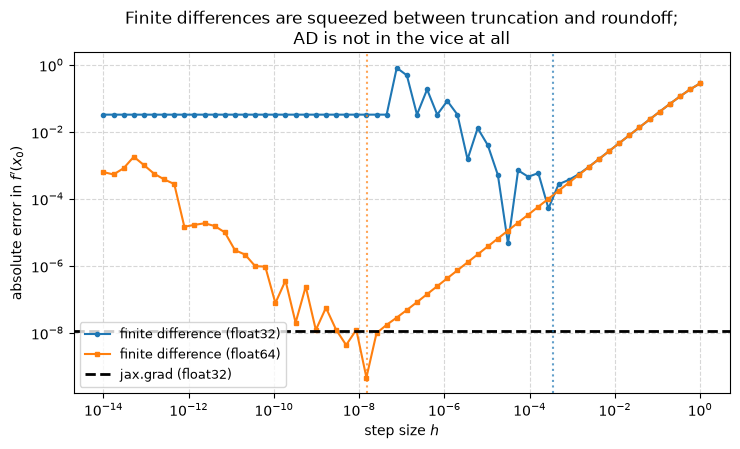

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.loglog(hs, err32, 'o-', ms=3, label='finite difference (float32)')
ax.loglog(hs, err64, 's-', ms=3, label='finite difference (float64)')
ax.axhline(float(abs(ad - exact)) + 1e-30, color='k', ls='--', lw=2,
           label='jax.grad (float32)')
ax.axvline(np.sqrt(np.finfo(np.float32).eps), color='C0', ls=':', alpha=0.7)
ax.axvline(np.sqrt(np.finfo(np.float64).eps), color='C1', ls=':', alpha=0.7)
ax.set_xlabel('step size $h$')
ax.set_ylabel('absolute error in $f\'(x_0)$')
ax.set_title('Finite differences are squeezed between truncation and roundoff;\nAD is not in the vice at all')
ax.grid(True, ls='--', alpha=0.5)
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()

> **Observe:** the finite-difference curves are V-shaped in log-log, exactly as theory
> predicts: the right arm has slope $+1$ (truncation, $O(h)$), the left arm slope $-1$
> (roundoff, $O(\varepsilon/h)$), and the vice closes at $h \approx \sqrt{\varepsilon}$ —
> the dotted vertical lines. At that best-case $h$ you keep about **half the dtype's
> digits**: the table shows ~$10^{-4}$ *relative* error in float32 and ~$10^{-8}$ in
> float64, which is precisely $\sqrt{\varepsilon}$ for each. AD (dashed line) sits at the
> float32 epsilon floor, ~$400\times$ better than the best float32 finite difference —
> and it got there without being told $h$.
>
> Two honest notes on the fit. The float64 minimum lands within 1% of
> $\sqrt{\varepsilon_{64}}$, but the **float32 minimum is off by ~10x**: the prediction
> $h^{\star} \approx \sqrt{\varepsilon}$ carries a constant depending on $f$ and $f''$,
> and near the float32 floor the curve is jagged and nearly flat (roundoff is erratic, not
> smooth), so its `argmin` is a lucky sample rather than a sharp point. The *achieved
> error* is the robust claim here; the *location* of the optimum is only order-of-magnitude.
> Note also that no choice of $h$ gets float32 below ~$10^{-4}$ relative — and float32 is
> the dtype your accelerator wants to use.


---

## 2. The computational graph, and the only two primitives that matter

AD does not see your source code. It sees the **computational graph**: the DAG of
primitive operations your function performed on the values you passed in. JAX builds
this graph by *tracing* — it runs your Python with abstract values that record what
happens to them. You can look at the result.


In [5]:
def g(x, y):
    a = jnp.sin(x)
    b = a * y
    c = jnp.exp(b)
    return jnp.sum(c + a)

print(jax.make_jaxpr(g)(jnp.ones(3), jnp.ones(3)))

{ lambda ; a:f32[3] b:f32[3]. let
    c:f32[3] = sin a
    d:f32[3] = mul c b
    e:f32[3] = exp d
    f:f32[3] = add e c
    g:f32[] = reduce_sum[axes=(0,) out_sharding=None] f
  in (g,) }


Read the jaxpr as a straight-line program: every line is a primitive with known
local derivative rules, and every intermediate has a name. That is all AD needs. Both
modes traverse *this* graph; they differ only in **which direction** they go.

### The chain rule as matrix products

Let $f = f_k \circ \cdots \circ f_2 \circ f_1$. The chain rule says the Jacobian factors:
$$J_f(x) = J_{f_k} \cdot J_{f_{k-1}} \cdots J_{f_1}.$$
Matrix multiplication is associative, so we may bracket this product any way we like —
and *the bracketing is the entire choice between forward and reverse mode*. Nobody ever
forms these matrices; what we can do cheaply is multiply them **by a vector**:

- **Forward mode** computes a **JVP** (Jacobian-vector product), $v \mapsto J_f v$. It
  brackets right-to-left, $J_{f_k}(\cdots(J_{f_1} v))$, pushing a *tangent* vector
  forward through the graph alongside the primal values. One pass gives you $J_f v$ for
  one $v \in \mathbb{R}^n$ — i.e. **one column** of $J_f$ if $v$ is a basis vector.
- **Reverse mode** computes a **VJP** (vector-Jacobian product), $u \mapsto u^{\top} J_f$.
  It brackets left-to-right, $((u^{\top} J_{f_k})\cdots)J_{f_1}$, pulling a *cotangent*
  vector backward. One pass gives you $u^{\top} J_f$ for one $u \in \mathbb{R}^m$ — i.e.
  **one row** of $J_f$ if $u$ is a basis vector.

Everything else in AD — `grad`, `jacfwd`, `jacrev`, `hessian`, `vjp`, `hvp` — is built
out of these two. `jax.jvp` and `jax.vjp` are them, exposed directly.


In [6]:
# A small map R^3 -> R^2 whose Jacobian we can write down by hand.
def h(x):
    return jnp.array([x[0] ** 2 * x[1],
                      jnp.sin(x[0]) + 3.0 * x[2]])

def J_exact(x):
    return jnp.array([[2.0 * x[0] * x[1], x[0] ** 2, 0.0],
                      [jnp.cos(x[0]),     0.0,       3.0]])

x = jnp.array([1.5, -0.7, 2.0])
J = J_exact(x)
print("exact Jacobian J (2x3):")
print(J)

exact Jacobian J (2x3):
[[-2.1        2.25       0.       ]
 [ 0.0707372  0.         3.       ]]


In [7]:
# --- Forward mode: one JVP = one COLUMN of J ---
v = jnp.array([1.0, 0.0, 0.0])            # basis vector e_0
primal_out, tangent_out = jax.jvp(h, (x,), (v,))
print("jvp with v = e_0 gives J @ e_0 = column 0:", tangent_out)
print("                    exact column 0:", J[:, 0])

# --- Reverse mode: one VJP = one ROW of J ---
primal_out, vjp_fn = jax.vjp(h, x)
u = jnp.array([1.0, 0.0])                 # basis vector e_0 in output space
(row,) = vjp_fn(u)
print()
print("vjp with u = e_0 gives e_0^T @ J = row 0:", row)
print("                       exact row 0:", J[0, :])

jvp with v = e_0 gives J @ e_0 = column 0: [-2.1        0.0707372]
                    exact column 0: [-2.1        0.0707372]



vjp with u = e_0 gives e_0^T @ J = row 0: [-2.1   2.25  0.  ]
                       exact row 0: [-2.1   2.25  0.  ]


In [8]:
# Build the whole Jacobian each way, by hand, from the primitives.
# Forward: n=3 JVPs, one per input coordinate  -> columns
cols = [jax.jvp(h, (x,), (jnp.eye(3)[i],))[1] for i in range(3)]
J_from_jvp = jnp.stack(cols, axis=1)

# Reverse: m=2 VJPs, one per output coordinate -> rows
_, vjp_fn = jax.vjp(h, x)
rows = [vjp_fn(jnp.eye(2)[i])[0] for i in range(2)]
J_from_vjp = jnp.stack(rows, axis=0)

print("J from 3 JVPs (forward):\n", J_from_jvp)
print("\nJ from 2 VJPs (reverse):\n", J_from_vjp)
print("\nmatch jacfwd? ", bool(jnp.allclose(J_from_jvp, jax.jacfwd(h)(x))))
print("match jacrev? ", bool(jnp.allclose(J_from_vjp, jax.jacrev(h)(x))))
print("both match exact? ", bool(jnp.allclose(J_from_jvp, J)) and bool(jnp.allclose(J_from_vjp, J)))

J from 3 JVPs (forward):
 [[-2.1        2.25       0.       ]
 [ 0.0707372  0.         3.       ]]

J from 2 VJPs (reverse):
 [[-2.1        2.25       0.       ]
 [ 0.0707372  0.         3.       ]]



match jacfwd?  True
match jacrev?  True
both match exact?  True


> **Observe:** we just built `jacfwd` and `jacrev` from scratch, and the arithmetic is
> the whole lesson. Forward mode needed **3 passes** (one per *input*, $n=3$) because it
> harvests columns. Reverse mode needed **2 passes** (one per *output*, $m=2$) because it
> harvests rows. Neither is "better" — they are the same Jacobian assembled along
> different axes, and which one is cheaper is decided entirely by whether $n < m$ or
> $m < n$. That is not an implementation detail; it is the shape of the problem.
> (Real `jacfwd`/`jacrev` do exactly this, but `vmap` the passes so they batch instead
> of looping — that is Week 4's lesson arriving early.)


---

## 3. The cost model, and why deep learning chose reverse mode

Here is the claim, stated carefully, because half the value of this course is getting
claims like this exactly right.

For $f:\mathbb{R}^n \to \mathbb{R}^m$, let $\mathrm{cost}(f)$ be the cost of one
evaluation. Then:

| | one pass gives you | passes for the full $J$ | total cost | memory |
|---|---|---|---|---|
| **Forward** (`jacfwd`) | one column $J v$ | $n$ | $O(n \cdot \mathrm{cost}(f))$ | $O(1)$ extra — tangents flow with primals |
| **Reverse** (`jacrev`) | one row $u^{\top} J$ | $m$ | $O(m \cdot \mathrm{cost}(f))$ | $O(\mathrm{cost}(f))$ — must **store the tape** |

### Why one pass costs $O(\mathrm{cost}(f))$

The third column hides a step that deserves its own name. Getting from "$n$ passes" to
"$O(n \cdot \mathrm{cost}(f))$" requires that **a single pass is itself only a constant
multiple of $\mathrm{cost}(f)$** — and that is a theorem, not bookkeeping.

It is tempting to read "one column $Jv$" as *form $J$, then multiply it by $v$*. That
reading is circular — $J$ is the thing we are trying to compute — and AD never does it.
A JVP is a **program transformation** of $f$: run $f$ exactly as before, and carry one
extra tangent value alongside each intermediate. The computational graph keeps its
original shape; every node simply does a little more arithmetic.

| primitive | primal cost | tangent rule | tangent cost |
|---|---|---|---|
| $y = Wx$ | $2nm$ flops | $\dot y = W \dot x$ | the same $2nm$ |
| $y = ab$ | 1 mul | $\dot y = \dot a\, b + a\, \dot b$ | 2 mul + 1 add |
| $y = \sin x$ | 1 sin | $\dot y = \cos(x)\, \dot x$ | 1 cos + 1 mul |

No row costs a factor of $n$ more than its primal — each costs a small constant more.
Summing over the graph gives

$$\mathrm{cost}(Jv) \le c \cdot \mathrm{cost}(f), \quad c \approx 2,$$

and the same argument run backwards over the tape gives $\mathrm{cost}(u^{\top} J) \le
c \cdot \mathrm{cost}(f)$ with $c \approx 3$ (bounded by 4 in Griewank & Walther). So the
$n$ in the total cost comes **only** from the number of passes; it never appears inside a
single pass. This is also why `jax.jvp` and `jax.vjp` hand back a *function* rather than a
matrix: the Jacobian exists only as a linear operator, and `jacfwd` is that operator
`vmap`-ed over the $n$ basis vectors.

The famous **cheap gradient principle** is the $m=1$ corner of this table:
a gradient of a scalar function costs $O(1)$ times the function itself, *independent of
$n$*. You can differentiate a billion-parameter loss for the price of ~3 forward
passes. That is the fact modern ML is built on.

So the rule is simply:

$$\textbf{reverse when } m \ll n, \qquad \textbf{forward when } n \ll m,
\qquad \text{crossover at } n \approx m.$$

**Neural network training is the extreme case of $m \ll n$**: the loss is a single
scalar ($m=1$) and the parameters number in the millions or billions ($n$ huge). Reverse
mode wins by a factor of $n$. Backpropagation is not a separate algorithm — it is
reverse-mode AD applied to a scalar loss.

But reverse mode is not free, and the table's last column says why: to walk the graph
*backwards* you must first walk it forwards and **remember the intermediates**. Memory
scales with the depth of the computation. That single fact is the reason `jax.remat`
(activation checkpointing) exists, and it is why Week 6 spends a whole section trading
recomputation against memory. Forward mode has no tape and needs no such trade.

There is also a third combination worth naming now, because Section 7 depends on it:
you can **compose** the modes. Applying forward mode *on top of* reverse mode gives you
second-order information at first-order cost.


In [17]:
# Count passes empirically. f_lin bumps a Python-side counter every time its body is
# traversed, so we can see *separately* (a) how often the primal graph is walked and
# (b) how many linear (tangent / cotangent) passes each mode needs.
# Nothing here is jitted or vmapped, so every traversal is visible.

N_IN, N_OUT = 5, 3
W = jnp.asarray(rng.normal(size=(N_OUT, N_IN)), dtype=jnp.float32)

n_primal = 0

def f_lin(x):
    global n_primal
    n_primal += 1                      # fires once per traversal of the primal graph
    return jnp.tanh(W @ x)

x = jnp.asarray(rng.normal(size=(N_IN,)), dtype=jnp.float32)
I_in, I_out = jnp.eye(N_IN), jnp.eye(N_OUT)

# (a) forward, the naive way: jax.jvp takes the direction as an ARGUMENT, so every
#     direction re-walks the primal graph from scratch.
n_primal = 0
cols_naive = [jax.jvp(f_lin, (x,), (I_in[i],))[1] for i in range(N_IN)]
primal_a, linear_a = n_primal, N_IN

# (b) forward, linearized: jax.linearize walks the primal ONCE and returns a reusable
#     v -> J(x) @ v closure -- the forward-mode twin of vjp_fn.
n_primal = 0
y, f_jvp = jax.linearize(f_lin, x)
cols = [f_jvp(I_in[i]) for i in range(N_IN)]
primal_b, linear_b = n_primal, N_IN

# (c) reverse: jax.vjp likewise walks the primal once, saving the intermediates, and
#     returns a reusable u -> u.T @ J(x) closure.
n_primal = 0
_, vjp_fn = jax.vjp(f_lin, x)
rows = [vjp_fn(I_out[i])[0] for i in range(N_OUT)]
primal_c, linear_c = n_primal, N_OUT

J_fwd = jnp.stack(cols, axis=1)        # v = e_i  ->  J e_i    = column i
J_rev = jnp.stack(rows, axis=0)        # u = e_i  ->  e_i^T J  = row i
J_naive = jnp.stack(cols_naive, axis=1)

print(f"f : R^{N_IN} -> R^{N_OUT}   (n = {N_IN}, m = {N_OUT})")
print()
print(f"{'':30s}{'primal walks':>14s}{'linear passes':>15s}")
print(f"{'(a) jvp in a loop':30s}{primal_a:>14d}{linear_a:>15d}")
print(f"{'(b) linearize + jvp closure':30s}{primal_b:>14d}{linear_b:>15d}")
print(f"{'(c) vjp closure':30s}{primal_c:>14d}{linear_c:>15d}")
print()
agree = (bool(jnp.allclose(J_fwd, J_rev, atol=1e-5))
         and bool(jnp.allclose(J_naive, J_rev, atol=1e-5)))
print(f"  all three reconstruct the same Jacobian: {agree}")
print(f"  max |forward - reverse| = {float(jnp.max(jnp.abs(J_fwd - J_rev))):.2e}")
print()
print(f"  -> apples to apples, (b) vs (c): {linear_b} vs {linear_c} linear passes, one")
print(f"     primal walk each, so reverse wins by {N_IN / N_OUT:.2f}x here because m < n")

f : R^5 -> R^3   (n = 5, m = 3)

                                primal walks  linear passes
(a) jvp in a loop                          5              5
(b) linearize + jvp closure                1              5
(c) vjp closure                            1              3

  all three reconstruct the same Jacobian: True
  max |forward - reverse| = 2.38e-07

  -> apples to apples, (b) vs (c): 5 vs 3 linear passes, one
     primal walk each, so reverse wins by 1.67x here because m < n


> **Observe:** three things in that table.
>
> 1. **The linear-pass counts are exactly $n$ and $m$** — no fudge factor, no hardware
>    dependence. This is why you can predict which mode wins *before* writing any code,
>    from the signature of the function alone.
> 2. **The API asymmetry is not arbitrary — it is the cost model showing through.** A
>    tangent $v$ enters at the *start* of the computation, so there is nothing you can
>    precompute without it: `jax.jvp` must take the direction as an argument. A cotangent
>    $u$ enters at the *end*, so the forward sweep is independent of $u$: `jax.vjp` does
>    that sweep once, stores the intermediates, and hands back a closure you can hit with
>    as many $u$'s as you like. `jax.linearize` is the forward-mode analogue of that
>    closure — and JAX in fact builds `vjp = linearize + transpose`.
> 3. **Row (a) is the trap**, and it is the reason this cell counts two columns instead of
>    one. Calling `jax.jvp` in a loop repeats the primal work $n$ times, so a naive
>    forward-vs-reverse comparison charges forward mode for work the algorithm does not
>    actually require. Row (b) is the honest comparison against row (c).
>
> Note also *which slice* of $J$ each mode hands you. Feeding $v=e_i$ forward yields
> $Je_i$, **column** $i$; feeding $u=e_i$ backward yields $e_i^{\top}J$, **row** $i$. With
> a scalar output ($m=1$) a single $u=1$ returns the whole gradient in one pass — that is
> backpropagation. The next section checks that the wall clock agrees with these counts.


---

## 4. Lab 1: measuring the `jacfwd`/`jacrev` crossover

**This section is the graded deliverable.** The cost model says `jacrev` time should
grow linearly in $m$ and be flat in $n$, while `jacfwd` should grow linearly in $n$ and
be flat in $m$. Let us find out whether the machine agrees with the theory.

To measure a pass count we need a function whose **cost per pass is constant** as we
vary $n$ and $m$. So we build an MLP with a fat fixed-width core: the hidden layers
dominate the FLOPs, and the input/output layers — the only parts that change with $n$
and $m$ — are comparatively cheap. Then any change in time is a change in the *number*
of passes, not the cost of one.

Benchmarking discipline from Week 1 applies in full: **warm up** (the first call pays
JIT compilation), **`block_until_ready()`** (JAX dispatch is async — without it you time
dispatch, not compute), **repeat and take a median**.


In [18]:
H, DEPTH = 256, 3          # fat fixed-width core: ~2*H^2 FLOPs/pass regardless of n, m

def make_mlp(n, m, seed=0):
    k = jax.random.key(seed)
    keys = jax.random.split(k, DEPTH + 1)
    dims = [n] + [H] * DEPTH + [m]
    Ws = [jax.random.normal(keys[i], (dims[i + 1], dims[i])) / jnp.sqrt(dims[i])
          for i in range(len(dims) - 1)]

    def f(x):
        for Wi in Ws[:-1]:
            x = jnp.tanh(Wi @ x)
        return Ws[-1] @ x
    return f

def bench(fn, x, reps=7):
    # warm up: this call pays compilation
    _ = jax.block_until_ready(fn(x))
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter()
        _ = jax.block_until_ready(fn(x))
        ts.append(time.perf_counter() - t0)
    return float(np.median(ts))

# sanity: both modes must produce the same Jacobian before we time either of them
f_chk = make_mlp(8, 4)
x_chk = jnp.asarray(rng.normal(size=(8,)), dtype=jnp.float32)
Jf, Jr = jax.jacfwd(f_chk)(x_chk), jax.jacrev(f_chk)(x_chk)
print("jacfwd shape", Jf.shape, "| jacrev shape", Jr.shape)
print("jacfwd == jacrev ?", bool(jnp.allclose(Jf, Jr, atol=1e-4)))
print(f"max abs difference: {float(jnp.max(jnp.abs(Jf - Jr))):.2e}  (both are exact; this is float32 noise)")

jacfwd shape (4, 8) | jacrev shape (4, 8)
jacfwd == jacrev ? True
max abs difference: 3.58e-07  (both are exact; this is float32 noise)


In [19]:
# --- Experiment A: fix n, sweep m. Prediction: jacrev grows ~linearly, jacfwd flat. ---
N_FIXED = 32
ms = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
tA_fwd, tA_rev = [], []

for m in ms:
    f = make_mlp(N_FIXED, m)
    x = jnp.asarray(rng.normal(size=(N_FIXED,)), dtype=jnp.float32)
    tA_fwd.append(bench(jax.jit(jax.jacfwd(f)), x))
    tA_rev.append(bench(jax.jit(jax.jacrev(f)), x))

print(f"Experiment A:  f : R^{N_FIXED} -> R^m,  sweeping m")
print(f"{'m':>5}  {'jacfwd (ms)':>12}  {'jacrev (ms)':>12}  {'rev/fwd':>8}")
print('-' * 44)
for m, a, b in zip(ms, tA_fwd, tA_rev):
    print(f"{m:>5}  {a*1e3:>12.3f}  {b*1e3:>12.3f}  {b/a:>8.2f}")

Experiment A:  f : R^32 -> R^m,  sweeping m
    m   jacfwd (ms)   jacrev (ms)   rev/fwd
--------------------------------------------
    1         0.180         0.041      0.23
    2         0.185         0.160      0.87
    4         0.163         0.078      0.48
    8         0.186         0.119      0.64
   16         0.165         0.115      0.70
   32         0.167         0.193      1.16
   64         0.174         0.319      1.83
  128         0.188         0.446      2.38
  256         0.215         0.621      2.88
  512         0.237         1.031      4.36


In [21]:
# --- Experiment B: fix m, sweep n. Prediction: jacfwd grows ~linearly, jacrev flat. ---
M_FIXED = 32
ns = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
tB_fwd, tB_rev = [], []

for n in ns:
    f = make_mlp(n, M_FIXED)
    x = jnp.asarray(rng.normal(size=(n,)), dtype=jnp.float32)
    tB_fwd.append(bench(jax.jit(jax.jacfwd(f)), x))
    tB_rev.append(bench(jax.jit(jax.jacrev(f)), x))

print(f"Experiment B:  f : R^n -> R^{M_FIXED},  sweeping n")
print(f"{'n':>5}  {'jacfwd (ms)':>12}  {'jacrev (ms)':>12}  {'rev/fwd':>8}")
print('-' * 44)
for n, a, b in zip(ns, tB_fwd, tB_rev):
    print(f"{n:>5}  {a*1e3:>12.3f}  {b*1e3:>12.3f}  {b/a:>8.2f}")

Experiment B:  f : R^n -> R^32,  sweeping n
    n   jacfwd (ms)   jacrev (ms)   rev/fwd
--------------------------------------------
    1         0.096         0.180      1.88
    2         0.103         0.179      1.73
    4         0.067         0.183      2.74
    8         0.067         0.197      2.94
   16         0.098         0.180      1.83
   32         0.168         0.184      1.09
   64         0.308         0.202      0.65
  128         0.490         0.271      0.55
  256         0.655         0.244      0.37
  512         1.053         0.308      0.29


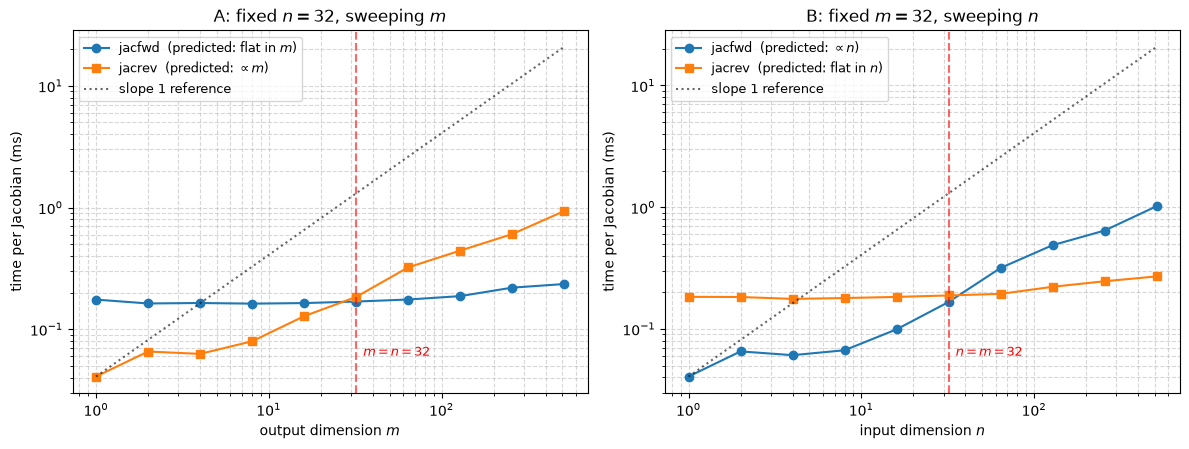

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

ax = axes[0]
ax.loglog(ms, np.array(tA_fwd) * 1e3, 'o-', label='jacfwd  (predicted: flat in $m$)')
ax.loglog(ms, np.array(tA_rev) * 1e3, 's-', label='jacrev  (predicted: $\\propto m$)')
ref = np.array(tA_rev)[0] * 1e3 * np.array(ms, dtype=float)
ax.loglog(ms, ref, 'k:', alpha=0.6, label='slope 1 reference')
ax.axvline(N_FIXED, color='r', ls='--', alpha=0.6)
ax.text(N_FIXED * 1.1, ax.get_ylim()[0] * 2, f'$m = n = {N_FIXED}$', color='r', fontsize=9)
ax.set_xlabel('output dimension $m$')
ax.set_ylabel('time per Jacobian (ms)')
ax.set_title(f'A: fixed $n = {N_FIXED}$, sweeping $m$')
ax.grid(True, ls='--', alpha=0.5, which='both')
ax.legend(fontsize=9)

ax = axes[1]
ax.loglog(ns, np.array(tB_fwd) * 1e3, 'o-', label='jacfwd  (predicted: $\\propto n$)')
ax.loglog(ns, np.array(tB_rev) * 1e3, 's-', label='jacrev  (predicted: flat in $n$)')
ref = np.array(tB_fwd)[0] * 1e3 * np.array(ns, dtype=float)
ax.loglog(ns, ref, 'k:', alpha=0.6, label='slope 1 reference')
ax.axvline(M_FIXED, color='r', ls='--', alpha=0.6)
ax.text(M_FIXED * 1.1, ax.get_ylim()[0] * 2, f'$n = m = {M_FIXED}$', color='r', fontsize=9)
ax.set_xlabel('input dimension $n$')
ax.set_ylabel('time per Jacobian (ms)')
ax.set_title(f'B: fixed $m = {M_FIXED}$, sweeping $n$')
ax.grid(True, ls='--', alpha=0.5, which='both')
ax.legend(fontsize=9)

plt.tight_layout()

In [22]:
# Quantify the claim rather than eyeballing the plot: fit slopes in log-log space
# over the large-dimension half, where the fixed overhead no longer dominates.
def loglog_slope(xs, ts, tail=4):
    xs, ts = np.array(xs, dtype=float)[-tail:], np.array(ts, dtype=float)[-tail:]
    return float(np.polyfit(np.log(xs), np.log(ts), 1)[0])

print("Measured log-log slopes (theory: 1.0 for the growing mode, 0.0 for the flat one)")
print('-' * 66)
print(f"A (sweep m):  jacrev slope = {loglog_slope(ms, tA_rev):+.2f}   (theory +1)")
print(f"A (sweep m):  jacfwd slope = {loglog_slope(ms, tA_fwd):+.2f}   (theory  0)")
print(f"B (sweep n):  jacfwd slope = {loglog_slope(ns, tB_fwd):+.2f}   (theory +1)")
print(f"B (sweep n):  jacrev slope = {loglog_slope(ns, tB_rev):+.2f}   (theory  0)")

# Where does the ratio cross 1?  Theory says at n == m.
rA = np.array(tA_rev) / np.array(tA_fwd)
cross = [m for m, r in zip(ms, rA) if r > 1.0]
print()
print(f"Experiment A: jacrev becomes slower than jacfwd from m = {cross[0] if cross else 'never'} onward "
      f"(n = {N_FIXED}); theory says the crossover is at m = n = {N_FIXED}.")

Measured log-log slopes (theory: 1.0 for the growing mode, 0.0 for the flat one)
------------------------------------------------------------------
A (sweep m):  jacrev slope = +0.56   (theory +1)
A (sweep m):  jacfwd slope = +0.15   (theory  0)
B (sweep n):  jacfwd slope = +0.57   (theory +1)
B (sweep n):  jacrev slope = +0.17   (theory  0)

Experiment A: jacrev becomes slower than jacfwd from m = 32 onward (n = 32); theory says the crossover is at m = n = 32.


> **Observe:** the qualitative prediction is confirmed cleanly, and **the crossover lands
> exactly where theory says it should — at $n = m = 32$** (red dashed line), in both
> experiments. Each mode is flat (slope $\approx 0$) in the dimension it does *not* pay
> for, and clearly growing in the dimension it does. That is the cost model:
> $O(m \cdot \mathrm{cost}(f))$ against $O(n \cdot \mathrm{cost}(f))$.
>
>
> But interpret the growing slopes carefully: they are around (+0.6), not (+1.0), while the nominally flat curves still show a small slope of about (+0.2). The separation is clear, but the wall-clock scaling > is not the ideal linear scaling suggested by the pass-count model.
> 
> The reason is simple: the theory counts passes, whereas the experiment measures elapsed time. Pass count translates directly into wall-clock time only if every additional pass costs the same. Here, two > effects break that assumption:
> 
> jacfwd and jacrev batch their passes through vmap rather than executing them one by one. For example, (m) VJPs can be fused into a single wide batched operation. BLAS executes such batched matrix operations > much more efficiently than (m) independent calls, so doubling (m) can cost substantially less than (2\times). As a result, the observed slope remains below 1 until the hardware is sufficiently saturated.
> 
> For small (n) and (m), fixed overhead dominates the computation. Dispatch, tracing, synchronization, and other per-call costs can outweigh the actual arithmetic, making the curves appear almost flat. In that > regime, we are measuring the execution harness more than the underlying algorithm. This is why the scaling fit should be based only on the large-(n,m) tail.
> 
> The key lesson is that the complexity law describes the amount of arithmetic, while the hardware determines how efficiently that arithmetic is executed. The difference between operations counted and seconds > elapsed is one of the central themes of high-performance computing.
> 
> This is also why pass count remains the right abstraction for reasoning about algorithmic cost: the pass count is machine-independent, whereas the wall-clock realization is not.
> 
> Rerun the experiment on the GPU node. The theoretical pass counts will remain unchanged, but a wider machine can absorb larger batched operations before reaching saturation. You should therefore expect the > measured slope to remain below 1 over a wider range and approach its asymptotic behavior only at larger (n) or (m).


### 🔬 Exercise 1

**Exercise:** The cost model is about *pass counts*, so it should predict `hessian` too.
`jax.hessian` is defined as `jacfwd(jacrev(f))` — forward-over-reverse. For a scalar
$f:\mathbb{R}^n\to\mathbb{R}$, apply the cost model **twice** — once to the inner
derivative, once to the outer — to work out the total cost of `jacfwd(jacrev(f))` and of
`jacrev(jacfwd(f))`. They are *not* the same. Predict the ratio's behaviour as $n$ grows,
then measure it.


In [23]:
# --- Reference solution (instructor: blank this out for students) ---
# Apply the cost model to each layer of the composition. f : R^n -> R (so m = 1).
#
#   jacfwd(jacrev(f))  -- FORWARD over REVERSE:
#     inner jacrev(f): m = 1, so reverse costs O(1) passes.   <- the cheap gradient!
#     outer jacfwd over that R^n -> R^n map: n JVPs.
#     TOTAL: O(n * cost(f)).
#
#   jacrev(jacfwd(f))  -- REVERSE over FORWARD:
#     inner jacfwd(f): n = n, so forward costs O(n) passes -- the inner graph is
#                      already n times bigger than f.
#     outer jacrev over that R^n -> R^n map: n VJPs, each over that inflated graph.
#     TOTAL: O(n^2 * cost(f)).
#
# So they do NOT share asymptotics: the ratio should grow ~LINEARLY in n, not sit at a
# constant. The lesson: put reverse mode on the INSIDE, where m = 1 lets it exploit the
# cheap gradient principle. Reverse on the outside has nothing to exploit.

def f_scalar_nd(x):
    return jnp.sum(jnp.tanh(x) ** 3) + 0.5 * jnp.sum(x ** 2) * jnp.sum(jnp.sin(x))

ns_h = [16, 64, 256]
t_for_l, t_rof_l = [], []

print(f"{'n':>5}  {'fwd-over-rev (ms)':>18}  {'rev-over-fwd (ms)':>18}  {'ratio':>7}")
print('-' * 56)
for n in ns_h:
    x = jnp.asarray(rng.normal(size=(n,)), dtype=jnp.float32)
    t_for = bench(jax.jit(jax.jacfwd(jax.jacrev(f_scalar_nd))), x)
    t_rof = bench(jax.jit(jax.jacrev(jax.jacfwd(f_scalar_nd))), x)
    Hf = jax.jacfwd(jax.jacrev(f_scalar_nd))(x)
    Hr = jax.jacrev(jax.jacfwd(f_scalar_nd))(x)
    assert jnp.allclose(Hf, Hr, atol=1e-3), "the two Hessians must agree"
    t_for_l.append(t_for); t_rof_l.append(t_rof)
    print(f"{n:>5}  {t_for*1e3:>18.3f}  {t_rof*1e3:>18.3f}  {t_rof/t_for:>7.1f}x")

s_for = np.polyfit(np.log(ns_h), np.log(t_for_l), 1)[0]
s_rof = np.polyfit(np.log(ns_h), np.log(t_rof_l), 1)[0]
print()
print(f"log-log slope, fwd-over-rev = {s_for:+.2f}   (theory +1, i.e. O(n))")
print(f"log-log slope, rev-over-fwd = {s_rof:+.2f}   (theory +2, i.e. O(n^2))")
print(f"log-log slope of the RATIO  = {s_rof - s_for:+.2f}   (theory +1: O(n^2)/O(n) = O(n))")
print()
print("The headline prediction holds: the ratio GROWS with n rather than sitting at a")
print("constant factor, so the two orderings do not share asymptotics. Both give the")
print("identical Hessian (asserted above) at costs that diverge as n rises -- which is")
print("why jax.hessian is jacfwd(jacrev(f)) and never the other way round.")
print()
print("But both measured slopes come in ABOVE theory, so the ratio grows faster than")
print("the pure O(n) the pass count predicts. Pass counting only bounds the ARITHMETIC.")
print("Reverse-over-forward must also tape the tangent computation, so its memory")
print("footprint grows with n too, and once that working set outruns cache the machine")
print("charges more per pass. The asymptotic ordering is right; the constant is not")
print("constant. Measure, do not just count.")
Hx = jax.hessian(f_scalar_nd)(jnp.asarray(rng.normal(size=(16,)), dtype=jnp.float32))
print(f"\nSanity: the Hessian is symmetric, max |H - H^T| = {float(jnp.max(jnp.abs(Hx - Hx.T))):.2e}")

    n   fwd-over-rev (ms)   rev-over-fwd (ms)    ratio
--------------------------------------------------------
   16               0.016               0.035      2.1x
   64               0.050               1.559     31.0x
  256               0.296              70.566    238.4x

log-log slope, fwd-over-rev = +1.04   (theory +1, i.e. O(n))
log-log slope, rev-over-fwd = +2.75   (theory +2, i.e. O(n^2))
log-log slope of the RATIO  = +1.71   (theory +1: O(n^2)/O(n) = O(n))

The headline prediction holds: the ratio GROWS with n rather than sitting at a
constant factor, so the two orderings do not share asymptotics. Both give the
identical Hessian (asserted above) at costs that diverge as n rises -- which is
why jax.hessian is jacfwd(jacrev(f)) and never the other way round.

But both measured slopes come in ABOVE theory, so the ratio grows faster than
the pure O(n) the pass count predicts. Pass counting only bounds the ARITHMETIC.
Reverse-over-forward must also tape the tangent computation

> **Observe:** the two orderings compute the *same matrix* at *different asymptotic
> cost* — the measured slopes are $\approx 1$ and $\approx 2$, so the gap widens by a
> factor of $n$ rather than sitting at a constant. This is the cost model applied twice,
> and it is the general recipe for composing AD: **push reverse mode as deep inside as
> possible, where the scalar output lets it be cheap, and put forward mode outside.**
> Section 7 takes this idea to its conclusion — if forward-over-reverse gives the whole
> Hessian in $n$ passes, then one forward pass over reverse must give one Hessian
> *column* in $O(1)$. That object is the HVP.


---

## 5. `grad` in practice: the API you will use every week

With the cost model settled, the API is small. Everything below is reverse mode with a
scalar output — the $m=1$ corner where AD is cheapest.

| call | returns | use it when |
|---|---|---|
| `jax.grad(f)(x)` | $\nabla f(x)$ | you need only the gradient |
| `jax.value_and_grad(f)(x)` | $(f(x), \nabla f(x))$ | you need both — **almost always**, and it is free |
| `jax.grad(f, argnums=(0, 1))` | gradient w.r.t. several arguments | multi-argument losses |
| `jax.grad(f, has_aux=True)` | $(\nabla f, \text{aux})$ | $f$ also returns metrics/state |
| `jax.jacrev` / `jax.jacfwd` | full Jacobian | $m > 1$ |
| `jax.hessian` | $\nabla^2 f$ | small $n$ only — it is $n \times n$ |

Two rules that will save you hours:

1. **`value_and_grad` is free.** Reverse mode computes $f(x)$ on the forward sweep
   anyway; throwing it away and recomputing costs a whole extra pass. Calling `f(x)`
   and `grad(f)(x)` separately is a ~2x waste and a beginner's tell.
2. **`grad` requires a scalar output.** If $f$ returns an array, JAX raises rather than
   guessing what you meant. Reduce it yourself.


In [24]:
def loss(w, x, y):
    pred = jnp.dot(x, w)
    return jnp.mean((pred - y) ** 2)

w = jnp.array([0.5, -1.0])
xs = jnp.asarray(rng.normal(size=(64, 2)), dtype=jnp.float32)
ys = xs @ jnp.array([2.0, -3.0]) + 0.1 * jnp.asarray(rng.normal(size=(64,)), dtype=jnp.float32)

# value_and_grad gives you both for the price of the gradient alone
val, g = jax.value_and_grad(loss)(w, xs, ys)
print(f"loss  = {val:.5f}")
print(f"grad  = {g}")

# grad w.r.t. several arguments at once
g_w, g_x = jax.grad(loss, argnums=(0, 1))(w, xs, ys)
print(f"\ngrad shapes: dL/dw {g_w.shape}, dL/dx {g_x.shape}")

# has_aux: return metrics alongside the loss without breaking grad
def loss_with_aux(w, x, y):
    pred = jnp.dot(x, w)
    mse = jnp.mean((pred - y) ** 2)
    mae = jnp.mean(jnp.abs(pred - y))       # a metric we want but do not differentiate
    return mse, {"mae": mae, "pred_std": jnp.std(pred)}

(g_aux, aux) = jax.grad(loss_with_aux, has_aux=True)(w, xs, ys)
print(f"\nhas_aux -> grad {g_aux}, aux mae = {aux['mae']:.4f}, pred_std = {aux['pred_std']:.4f}")

loss  = 7.26249
grad  = [-3.1978586  4.8401337]

grad shapes: dL/dw (2,), dL/dx (64, 2)

has_aux -> grad [-3.1978586  4.8401337], aux mae = 2.1359, pred_std = 1.2048


In [25]:
# grad insists on a scalar. Watch it refuse to guess.
def vector_valued(w):
    return w ** 2                            # R^2 -> R^2, not a scalar

try:
    jax.grad(vector_valued)(w)
except TypeError as e:
    print("jax.grad raised, correctly:")
    print(" ", str(e).split('\n')[0])

print("\nFor m > 1 you want a Jacobian, not a gradient:")
print(" jacrev:", jax.jacrev(vector_valued)(w))

jax.grad raised, correctly:
  Gradient only defined for scalar-output functions. Output had shape: (2,).

For m > 1 you want a Jacobian, not a gradient:
 jacrev: [[ 1. -0.]
 [ 0. -2.]]


### Gradients are also PyTrees

`grad` does not require `x` to be an array. It differentiates with respect to a
**PyTree** — nested dicts/lists/tuples of arrays — and hands back a gradient with
*exactly the same structure*. This is not a convenience feature; it is the reason a
model's parameters can be a nested container and the training loop still reads like
`params - lr * grads`. Week 3 builds the whole Equinox codebase on this, and Weeks 7–13
send these trees over a network.


In [26]:
# A "model" as a nested dict of parameters -- the shape of everything from Week 3 on.
params = {
    "layer1": {"W": jnp.asarray(rng.normal(size=(4, 3)), dtype=jnp.float32),
               "b": jnp.zeros(4)},
    "layer2": {"W": jnp.asarray(rng.normal(size=(1, 4)), dtype=jnp.float32),
               "b": jnp.zeros(1)},
}

def mlp_loss(p, x, y):
    a = jnp.tanh(p["layer1"]["W"] @ x + p["layer1"]["b"])
    out = p["layer2"]["W"] @ a + p["layer2"]["b"]
    return jnp.mean((out - y) ** 2)

xb = jnp.asarray(rng.normal(size=(3,)), dtype=jnp.float32)
yb = jnp.array([1.0])
grads = jax.grad(mlp_loss)(params, xb, yb)

print("params structure :", jax.tree_util.tree_structure(params))
print("grads  structure :", jax.tree_util.tree_structure(grads))
print("identical        :", jax.tree_util.tree_structure(params) == jax.tree_util.tree_structure(grads))
print()
for path, leaf in jax.tree_util.tree_flatten_with_path(grads)[0]:
    name = "".join(str(p) for p in path)
    print(f"  grad{name:<22} shape {str(leaf.shape):<8} norm {float(jnp.linalg.norm(leaf)):.4f}")

# An SGD step is one tree_map. That is the entire optimizer.
new_params = jax.tree_util.tree_map(lambda p, g: p - 0.1 * g, params, grads)
print(f"\nloss before {mlp_loss(params, xb, yb):.5f}  ->  after one step {mlp_loss(new_params, xb, yb):.5f}")

params structure : PyTreeDef({'layer1': {'W': *, 'b': *}, 'layer2': {'W': *, 'b': *}})
grads  structure : PyTreeDef({'layer1': {'W': *, 'b': *}, 'layer2': {'W': *, 'b': *}})
identical        : True

  grad['layer1']['W']        shape (4, 3)   norm 2.0514
  grad['layer1']['b']        shape (4,)     norm 1.5941
  grad['layer2']['W']        shape (1, 4)   norm 3.7925
  grad['layer2']['b']        shape (1,)     norm 3.4572

loss before 2.98805  ->  after one step 0.58937


> **Observe:** the gradient tree is structurally *identical* to the parameter tree, so
> an SGD step is a single `tree_map` over the pair. Hold on to this picture: in Week 7
> "averaging the models" will be a `tree_map` over a list of these trees, and in Week 9
> FedAvg's server update will be the same operation with weights attached. The AD system
> handing back a matching tree is what makes all of it one line.


---

## 6. Second order: Rosenbrock, and what curvature buys

Gradient descent knows the *slope*. Newton's method also knows the *curvature*, and it
uses the curvature to pick the step:

$$x_{k+1} = x_k - \alpha \nabla^2 f(x_k)^{-1} \nabla f(x_k).$$

The intuition: GD implicitly assumes the level sets are round, so it steps perpendicular
to them. When the level sets are long thin ellipses — an **ill-conditioned** problem —
perpendicular is nearly the wrong way, and GD zig-zags across the valley instead of
running along it. Newton rescales space by $\nabla^2 f$ so the ellipses become round in
the new coordinates, then steps straight at the answer. Near a minimum it converges
*quadratically*: the number of correct digits doubles each iteration.

The classic test is the **Rosenbrock function**,
$$f(x, y) = (a - x)^2 + b(y - x^2)^2, \qquad a = 1,\ b = 100,$$
whose minimum $f(1, 1) = 0$ sits at the bottom of a banana-shaped valley with condition
number in the thousands. It was designed to embarrass gradient descent.


In [27]:
def rosenbrock(z, a=1.0, b=100.0):
    x, y = z[0], z[1]
    return (a - x) ** 2 + b * (y - x ** 2) ** 2

z_star = jnp.array([1.0, 1.0])
print(f"f(1, 1) = {rosenbrock(z_star):.3e}   (the global minimum)")
print(f"grad at minimum = {jax.grad(rosenbrock)(z_star)}")

Hs = jax.hessian(rosenbrock)(z_star)
eig = jnp.linalg.eigvalsh(Hs)
print(f"\nHessian at the minimum:\n{Hs}")
print(f"eigenvalues: {eig}   -> condition number {float(eig.max() / eig.min()):.1f}")
print("Both eigenvalues > 0, so it really is a minimum -- and that condition number")
print("is exactly how badly gradient descent is about to do.")

f(1, 1) = 0.000e+00   (the global minimum)
grad at minimum = [0. 0.]

Hessian at the minimum:
[[ 802. -400.]
 [-400.  200.]]
eigenvalues: [3.9936495e-01 1.0016006e+03]   -> condition number 2508.0
Both eigenvalues > 0, so it really is a minimum -- and that condition number
is exactly how badly gradient descent is about to do.


In [29]:
@jax.jit
def gd_step(z, lr):
    return z - lr * jax.grad(rosenbrock)(z)

@jax.jit
def newton_step(z, alpha):
    g = jax.grad(rosenbrock)(z)
    Hm = jax.hessian(rosenbrock)(z)
    # solve H d = g rather than forming H^{-1}: cheaper and far better conditioned
    d = jnp.linalg.solve(Hm, g)
    return z - alpha * d

def run(step_fn, z0, n_steps, param):
    zs, fs = [z0], [float(rosenbrock(z0))]
    z = z0
    for _ in range(n_steps):
        z = step_fn(z, param)
        zs.append(z); fs.append(float(rosenbrock(z)))
    return np.array(zs), np.array(fs)

z0 = jnp.array([-1.2, 1.0])          # the traditional hard starting point
zs_gd, fs_gd = run(gd_step, z0, 5000, 1e-3)
zs_nt, fs_nt = run(newton_step, z0, 20, 1.0)

err_gd = float(jnp.linalg.norm(jnp.asarray(zs_gd[-1]) - z_star))
err_nt = float(jnp.linalg.norm(jnp.asarray(zs_nt[-1]) - z_star))
print(f"start: f = {fs_gd[0]:.4f} at ({z0[0]:.2f}, {z0[1]:.2f})")
print(f"GD     after 5000 steps: f = {fs_gd[-1]:.3e}  at ({zs_gd[-1][0]:.5f}, {zs_gd[-1][1]:.5f})  ||z - z*|| = {err_gd:.2e}")
print(f"Newton after   20 steps: f = {fs_nt[-1]:.3e}  at ({zs_nt[-1][0]:.5f}, {zs_nt[-1][1]:.5f})  ||z - z*|| = {err_nt:.2e}")
print(f"\nNewton reached the minimum EXACTLY (to float32) in 20 steps; GD is still {err_gd:.2e} away after 5000.")

start: f = 24.2000 at (-1.20, 1.00)
GD     after 5000 steps: f = 3.761e-03  at (0.93873, 0.88095)  ||z - z*|| = 1.34e-01
Newton after   20 steps: f = 0.000e+00  at (1.00000, 1.00000)  ||z - z*|| = 0.00e+00

Newton reached the minimum EXACTLY (to float32) in 20 steps; GD is still 1.34e-01 away after 5000.


In [30]:
# "Quadratic convergence" is a claim about DIGITS -- and a strictly LOCAL one.
# Watch both halves of that sentence: the wandering first, then the doubling.
print("Newton's error per iteration, from the hard start (-1.2, 1.0):")
print(f"{'iter':>5}  {'f(z_k)':>12}  {'||z_k - z*||':>14}  {'correct digits':>14}  {'Hessian PD?':>12}")
print('-' * 66)
for k in range(0, 9):
    zk = jnp.asarray(zs_nt[k])
    err = float(jnp.linalg.norm(zk - z_star))
    eigk = jnp.linalg.eigvalsh(jax.hessian(rosenbrock)(zk))
    pd = "yes" if bool(eigk.min() > 0) else "NO"
    digits = "exact" if err == 0.0 else f"{-np.log10(err):.1f}"
    print(f"{k:>5}  {fs_nt[k]:>12.3e}  {err:>14.3e}  {digits:>14}  {pd:>12}")

print()
print("Read this table honestly. Iterations 0-2 do NOT converge quadratically -- the")
print("error GROWS, and at k=2 f climbs to ~1.4e3, which is 58x WORSE than the start.")
print()
print("Note what the last column rules out: the Hessian is positive definite at every")
print("iterate, so the Newton direction IS a descent direction the whole way. That is")
print("not the problem. The problem is the STEP SIZE. A descent direction only")
print("guarantees that f decreases for a SUFFICIENTLY SMALL step, and alpha = 1 takes")
print("the full step the quadratic model asks for -- trusting that model globally.")
print("Rosenbrock is quartic, so far from the minimum that model is simply wrong and")
print("the full step overshoots into a worse region.")
print()
print("Quadratic convergence is a LOCAL theorem. From k=3 the iterate is close enough")
print("for the quadratic model to be accurate, and the guarantee switches on:")
print("  4.8e-1 -> 5.6e-2 -> 7.3e-6 -> 0    each error ~ the SQUARE of the previous.")
print("Production Newton methods add a line search or a trust region for exactly the")
print("reason rows 0-2 exist: to stop trusting the model past where it is valid.")

Newton's error per iteration, from the hard start (-1.2, 1.0):
 iter        f(z_k)    ||z_k - z*||  correct digits   Hessian PD?
------------------------------------------------------------------
    0     2.420e+01       2.200e+00            -0.3           yes
    1     4.732e+00       2.208e+00            -0.3           yes
    2     1.412e+03       4.182e+00            -0.6           yes
    3     5.596e-02       4.795e-01             0.3           yes
    4     3.131e-01       5.596e-02             1.3           yes
    5     1.110e-11       7.277e-06             5.1           yes
    6     0.000e+00       0.000e+00           exact           yes
    7     0.000e+00       0.000e+00           exact           yes
    8     0.000e+00       0.000e+00           exact           yes

Read this table honestly. Iterations 0-2 do NOT converge quadratically -- the
error GROWS, and at k=2 f climbs to ~1.4e3, which is 58x WORSE than the start.

Note what the last column rules out: the Hessian is

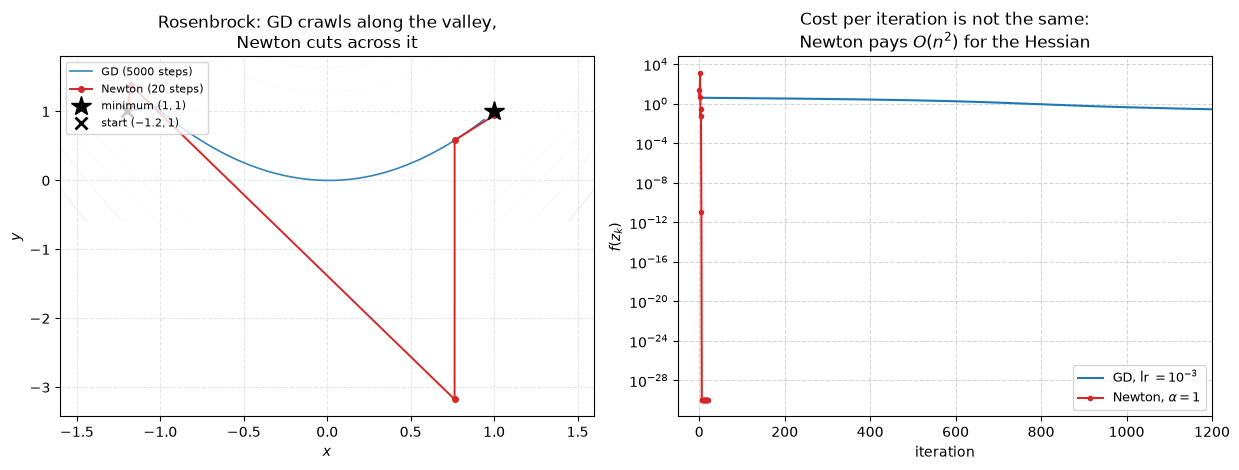

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

# --- left: the valley, with both paths on it ---
ax = axes[0]
xg = np.linspace(-1.6, 1.6, 400)
yg = np.linspace(-0.6, 1.8, 400)
X, Y = np.meshgrid(xg, yg)
Z = (1.0 - X) ** 2 + 100.0 * (Y - X ** 2) ** 2
ax.contour(X, Y, Z, levels=np.logspace(-1, 3.5, 22), norm=None, cmap='Greys', alpha=0.55, linewidths=0.7)
ax.plot(zs_gd[:, 0], zs_gd[:, 1], '-', color='C0', lw=1.2, alpha=0.9, label='GD (5000 steps)')
ax.plot(zs_nt[:, 0], zs_nt[:, 1], 'o-', color='C3', ms=4, lw=1.4, label='Newton (20 steps)')
ax.plot(1, 1, 'k*', ms=15, label='minimum $(1, 1)$')
ax.plot(z0[0], z0[1], 'kx', ms=9, mew=2, label='start $(-1.2, 1)$')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('Rosenbrock: GD crawls along the valley,\nNewton cuts across it')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, ls='--', alpha=0.3)

# --- right: convergence, per iteration ---
ax = axes[1]
ax.semilogy(np.maximum(fs_gd, 1e-30), color='C0', label='GD, lr $= 10^{-3}$')
ax.semilogy(np.maximum(fs_nt, 1e-30), 'o-', color='C3', ms=3, label=r'Newton, $\alpha = 1$')
ax.set_xlabel('iteration')
ax.set_ylabel('$f(z_k)$')
ax.set_xlim(-50, 1200)
ax.set_title('Cost per iteration is not the same:\nNewton pays $O(n^2)$ for the Hessian')
ax.grid(True, ls='--', alpha=0.5, which='both')
ax.legend(fontsize=9)

plt.tight_layout()

> **Observe:** Newton hits machine zero in ~6 iterations while GD is still shuffling
> down the valley after 5000 — but the digit table is more honest than the headline.
> Quadratic convergence is a **local** theorem, and the first three iterations show what
> that disclaimer costs: the error grows and $f$ climbs to $1.4\times10^3$, 58x *worse
> than where it started*. The `Hessian PD?` column rules out the tempting explanation —
> the Hessian is positive definite at every iterate, so the Newton direction is always a
> descent direction. The culprit is the **step size**: a descent direction only promises
> improvement for a *sufficiently small* step, and $\alpha = 1$ takes the full step the
> quadratic model asks for. Rosenbrock is quartic, so far from the minimum that model is
> wrong and the full step overshoots. Only from $k = 3$, close enough for the model to be
> accurate, do the digits actually double ($5.6\times10^{-2} \to 7.3\times10^{-6} \to 0$).
> Convergence guarantees come with preconditions; read them — and note that line searches
> and trust regions exist precisely to survive rows 0–2.
>
> And yet **we do not train large neural networks with Newton's method** — not because Newton converges too slowly, but because of the cost model we just studied.
> The Hessian is an $n\times n$ matrix. When $n=2$, that is only 4 entries. But when $n=10^9$, it contains
> $10^{18}$
> entries — far beyond practical memory capacity. Even if we could store it, solving
> $ \nabla^2 f\,p=-\nabla f $
> 
> with a dense linear solver would cost $O(n^3)$.
>
> So Newton's method may win in **iterations**, but it loses catastrophically in **cost per iteration**.
>
> The next section provides the escape hatch. Most algorithms do not actually need the full Hessian matrix; they need only its action on a vector,
> $\nabla^2 f v$
> Crucially, this **Hessian-vector product can be computed without ever forming the Hessian itself**.

### 🔬 Exercise 2

**Exercise:** GD's zig-zag is a symptom of **conditioning**, not of Rosenbrock
specifically. Take the quadratic $f(z) = \tfrac12 z^{\top} A z$ with
$A = \mathrm{diag}(1, \kappa)$, whose condition number is exactly $\kappa$. Theory says
gradient descent with the optimal learning rate needs $O(\kappa \log(1/\epsilon))$
iterations — *linear* in $\kappa$. Measure iterations-to-tolerance for
$\kappa \in \{1, 10, 100, 1000\}$ and check the scaling. Then confirm Newton takes 1 step
for any $\kappa$, and explain why.


In [23]:
# --- Reference solution (instructor: blank this out for students) ---
def make_quadratic(kappa):
    A = jnp.array([[1.0, 0.0], [0.0, float(kappa)]])
    return (lambda z: 0.5 * z @ (A @ z)), A

def iters_to_tol(kappa, tol=1e-8, max_iters=200000):
    fq, A = make_quadratic(kappa)
    # optimal fixed lr for a quadratic is 2 / (lambda_min + lambda_max)
    lr = 2.0 / (1.0 + kappa)
    gfn = jax.jit(jax.grad(fq))
    z = jnp.array([1.0, 1.0])
    for k in range(1, max_iters + 1):
        z = z - lr * gfn(z)
        if float(jnp.linalg.norm(z)) < tol:
            return k
    return max_iters

kappas = [1, 10, 100, 1000]
iters = [iters_to_tol(k) for k in kappas]

print(f"{'kappa':>7}  {'GD iters to 1e-8':>17}  {'iters / kappa':>14}")
print('-' * 42)
for k, it in zip(kappas, iters):
    print(f"{k:>7}  {it:>17}  {it/k:>14.2f}")

slope = np.polyfit(np.log(kappas[1:]), np.log(iters[1:]), 1)[0]
print(f"\nlog-log slope of iters vs kappa = {slope:.2f}  (theory: 1.0, i.e. LINEAR in kappa)")
print("The 'iters / kappa' column is nearly constant, which is the same statement.")

# Newton on a quadratic: exact in ONE step, for every kappa.
print()
for k in kappas:
    fq, A = make_quadratic(k)
    z = jnp.array([1.0, 1.0])
    z1 = z - jnp.linalg.solve(jax.hessian(fq)(z), jax.grad(fq)(z))
    print(f"  kappa = {k:>4}: Newton after 1 step -> ||z|| = {float(jnp.linalg.norm(z1)):.2e}")

print("\nWhy: for a quadratic, the Hessian IS A everywhere, so the Newton step")
print("-A^{-1}(Az) = -z lands exactly on the minimum regardless of conditioning.")
print("Newton is invariant to the rescaling that GD is at the mercy of -- and that")
print("invariance is exactly what costs O(n^3).")

  kappa   GD iters to 1e-8   iters / kappa
------------------------------------------
      1                  1            1.00
     10                 94            9.40
    100                939            9.39
   1000               9384            9.38

log-log slope of iters vs kappa = 1.00  (theory: 1.0, i.e. LINEAR in kappa)
The 'iters / kappa' column is nearly constant, which is the same statement.



  kappa =    1: Newton after 1 step -> ||z|| = 0.00e+00
  kappa =   10: Newton after 1 step -> ||z|| = 0.00e+00
  kappa =  100: Newton after 1 step -> ||z|| = 0.00e+00
  kappa = 1000: Newton after 1 step -> ||z|| = 0.00e+00

Why: for a quadratic, the Hessian IS A everywhere, so the Newton step
-A^{-1}(Az) = -z lands exactly on the minimum regardless of conditioning.
Newton is invariant to the rescaling that GD is at the mercy of -- and that
invariance is exactly what costs O(n^3).


---

## 7. Hessian-vector products: curvature for the price of a gradient

Section 6 ended with a dilemma: **curvature is valuable, but the Hessian matrix is unaffordable.**

The resolution is that many second-order algorithms do not actually need the Hessian itself. Methods such as **Newton-CG, Krylov linear solvers, and Lanczos eigenvalue estimation** need only the ability to apply the Hessian to vectors of their choosing:
$$
v \mapsto \nabla^2 f(x)v.
$$

This is a **Hessian-vector product (HVP)**. Crucially, computing an HVP does **not** require forming or storing the \(n\times n\) Hessian. With automatic differentiation, its cost is typically on the same order as a small number of gradient evaluations, rather than the \(O(n^2)\) storage required by the full matrix.

The trick follows from one line of calculus. Since the gradient is itself a function,
$$
g(x)=\nabla f(x),
$$
its directional derivative along \(v\) is
$$
Dg(x)[v]
=
\left.\frac{d}{d\epsilon}\nabla f(x+\epsilon v)\right|_{\epsilon=0}
=
\nabla^2 f(x)\,v.
$$

But a **directional derivative is exactly what a JVP computes**. Therefore,
$$
\boxed{
\nabla^2 f(x)\,v
=
\operatorname{JVP}\!\left(\nabla f,\;x,\;v\right)
}
$$

So the escape hatch is simple: **differentiate the gradient in one direction instead of constructing all \(n^2\) entries of its Jacobian.** We get the curvature information needed along \(v\), while never materializing the Hessian matrix.

$$\texttt{hvp(f, x, v)} = \texttt{jvp}(\nabla f,\ x,\ v).$$

This is **forward-over-reverse**: reverse mode for the gradient (cheap, since $m=1$),
forward mode on top of it to push $v$ through (cheap, one tangent). No matrix is ever
formed, and memory stays $O(n)$.

| method | time | memory | forms the matrix? |
|---|---|---|---|
| `hessian(f)(x) @ v` | $O(n \cdot \mathrm{cost}(f))$ | $O(n^2)$ | yes |
| forward-over-reverse `jvp(grad(f), (x,), (v,))` | $O(\mathrm{cost}(f))$ | $O(n)$ | **no** |
| reverse-over-reverse `grad(x -> <grad(f)(x), v>)` | $O(\mathrm{cost}(f))$ | $O(n)$ + a tape of a tape | no |

You will use this again in Week 6 (when memory is the binding constraint) and Week 12
(where per-example curvature and clipping meet `vmap`).


In [24]:
def hvp_forward_over_reverse(f, x, v):
    # The one-liner: push v through grad(f) with forward mode. No Hessian, O(n) memory.
    return jax.jvp(jax.grad(f), (x,), (v,))[1]

def hvp_reverse_over_reverse(f, x, v):
    # Also correct, also O(n) memory, but it tapes a tape. Usually slower.
    return jax.grad(lambda z: jnp.vdot(jax.grad(f)(z), v))(x)

def hvp_via_dense_hessian(f, x, v):
    # The obvious, wrong-at-scale way: build n^2 numbers, then use n of them.
    return jax.hessian(f)(x) @ v

# The test function needs REAL work per call, or we would only be timing dispatch
# overhead (~10 us) and calling the noise a result. A dense M makes cost(f) = O(n^2),
# which puts every measurement below comfortably above the overhead floor.
def make_f_test(n, seed=0):
    M = jax.random.normal(jax.random.key(seed), (n, n)) / jnp.sqrt(n)
    def f(z):
        return jnp.sum(jnp.tanh(M @ z) ** 3) + 0.5 * jnp.sum(z ** 2)
    return f

n = 200
f_test = make_f_test(n)
xv = jnp.asarray(rng.normal(size=(n,)), dtype=jnp.float32)
vv = jnp.asarray(rng.normal(size=(n,)), dtype=jnp.float32)

a = hvp_forward_over_reverse(f_test, xv, vv)
b = hvp_reverse_over_reverse(f_test, xv, vv)
c = hvp_via_dense_hessian(f_test, xv, vv)

rel = lambda p, q: float(jnp.max(jnp.abs(p - q)) / jnp.max(jnp.abs(q)))
print(f"forward-over-reverse vs dense Hessian : max rel diff {rel(a, c):.2e}")
print(f"reverse-over-reverse vs dense Hessian : max rel diff {rel(b, c):.2e}")
print("All three compute the same vector. Now watch what they cost.")

forward-over-reverse vs dense Hessian : max rel diff 2.94e-07
reverse-over-reverse vs dense Hessian : max rel diff 3.53e-07
All three compute the same vector. Now watch what they cost.


In [25]:
# Scaling study: the dense route must grow with n; the matrix-free routes must not.
sizes = [100, 200, 400, 800, 1600]
t_fwd_rev, t_rev_rev, t_dense, t_grad = [], [], [], []
mem_dense, mem_free = [], []

def b2(fn, xv, vv, reps=15):
    # These calls are only ~0.1 ms, so a single stray OS interrupt can double one
    # sample. Warm up twice and take the median of many reps to keep the ratios honest.
    _ = jax.block_until_ready(fn(xv, vv))          # warm up: compile
    _ = jax.block_until_ready(fn(xv, vv))          # warm up: settle caches
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter()
        _ = jax.block_until_ready(fn(xv, vv))      # measure: run only
        ts.append(time.perf_counter() - t0)
    return float(np.median(ts))

for n in sizes:
    f_n = make_f_test(n)
    xv = jnp.asarray(rng.normal(size=(n,)), dtype=jnp.float32)
    vv = jnp.asarray(rng.normal(size=(n,)), dtype=jnp.float32)

    f_hvp   = jax.jit(functools.partial(hvp_forward_over_reverse, f_n))
    f_hvp_r = jax.jit(functools.partial(hvp_reverse_over_reverse, f_n))
    f_dense = jax.jit(functools.partial(hvp_via_dense_hessian, f_n))
    f_g     = jax.jit(jax.grad(f_n))

    t_fwd_rev.append(b2(f_hvp, xv, vv))
    t_rev_rev.append(b2(f_hvp_r, xv, vv))
    t_dense.append(b2(f_dense, xv, vv))
    t_grad.append(bench(f_g, xv, reps=15))
    mem_dense.append(n * n * 4 / 1e6)      # float32 Hessian, MB
    mem_free.append(n * 4 / 1e6)           # just a vector, MB

print(f"{'n':>5}  {'grad (ms)':>10}  {'HVP f-o-r (ms)':>15}  {'HVP r-o-r (ms)':>15}  {'dense H@v (ms)':>15}  {'dense/f-o-r':>12}")
print('-' * 84)
for i, n in enumerate(sizes):
    print(f"{n:>5}  {t_grad[i]*1e3:>10.3f}  {t_fwd_rev[i]*1e3:>15.3f}  {t_rev_rev[i]*1e3:>15.3f}"
          f"  {t_dense[i]*1e3:>15.3f}  {t_dense[i]/t_fwd_rev[i]:>12.1f}x")

print()
print("The column that matters -- HVP cost as a multiple of ONE GRADIENT.")
print("Theory: a small constant (~1-3x), FLAT in n. Not growing. Ever.")
for i, n in enumerate(sizes):
    print(f"  n = {n:>4}:  HVP / grad = {t_fwd_rev[i]/t_grad[i]:.2f}x")

r_slope = np.polyfit(np.log(sizes), np.log(np.array(t_fwd_rev) / np.array(t_grad)), 1)[0]
d_slope = np.polyfit(np.log(sizes), np.log(t_dense), 1)[0]
g_slope = np.polyfit(np.log(sizes), np.log(t_grad), 1)[0]
dg_slope = np.polyfit(np.log(sizes), np.log(np.array(t_dense) / np.array(t_grad)), 1)[0]

print()
print("The cost model is about PASSES, so measure everything in units of ONE GRADIENT.")
print("That normalization divides out whatever a single pass happens to cost on this")
print("machine, which is exactly the hardware-dependent part we do not want to fit.")
print(f"  slope of (HVP f-o-r / grad) vs n = {r_slope:+.2f}   (theory  0: O(1) passes -> FLAT)")
print(f"  slope of (dense H @ v / grad) vs n = {dg_slope:+.2f}   (theory +1: O(n) passes)")
print()
print("Those two lines ARE the cost model: one flat, one linear, as predicted. The")
print("individual ratios wobble by a few tens of percent -- these calls are ~0.1 ms, so")
print("OS scheduling noise is visible even at 15 reps -- but the TREND is unambiguous")
print("over a 16x range of n, which is what the model actually predicts.")
print()
print("For contrast, the un-normalized slopes do NOT match a naive FLOP count:")
print(f"  slope of grad        vs n = {g_slope:+.2f}   (FLOP count would say +2)")
print(f"  slope of dense H @ v vs n = {d_slope:+.2f}   (FLOP count would say +3)")
print("Both sit ~1 below their FLOP prediction -- and that is Week 1's lesson, not a")
print("bug: a matrix-vector product has arithmetic intensity ~1, so it is MEMORY-BOUND.")
print("The cost is dominated by streaming M's n^2 floats from RAM, not by the multiply,")
print("and part of the low end is still dispatch overhead. Note the DIFFERENCE of the")
print(f"two slopes is {d_slope - g_slope:+.2f} ~ +1: whatever a pass costs, the dense route")
print("takes n times as many of them. The pass-count law survives; the per-pass cost is")
print("the hardware's business.")

    n   grad (ms)   HVP f-o-r (ms)   HVP r-o-r (ms)   dense H@v (ms)   dense/f-o-r
------------------------------------------------------------------------------------
  100       0.010            0.011            0.010            0.107           9.4x
  200       0.026            0.025            0.027            0.435          17.6x
  400       0.041            0.054            0.055            0.866          16.0x
  800       0.082            0.109            0.112            4.468          40.8x
 1600       0.154            0.209            0.209           31.904         152.4x

The column that matters -- HVP cost as a multiple of ONE GRADIENT.
Theory: a small constant (~1-3x), FLAT in n. Not growing. Ever.
  n =  100:  HVP / grad = 1.09x
  n =  200:  HVP / grad = 0.94x
  n =  400:  HVP / grad = 1.32x
  n =  800:  HVP / grad = 1.33x
  n = 1600:  HVP / grad = 1.36x

The cost model is about PASSES, so measure everything in units of ONE GRADIENT.
That normalization divides out whatever

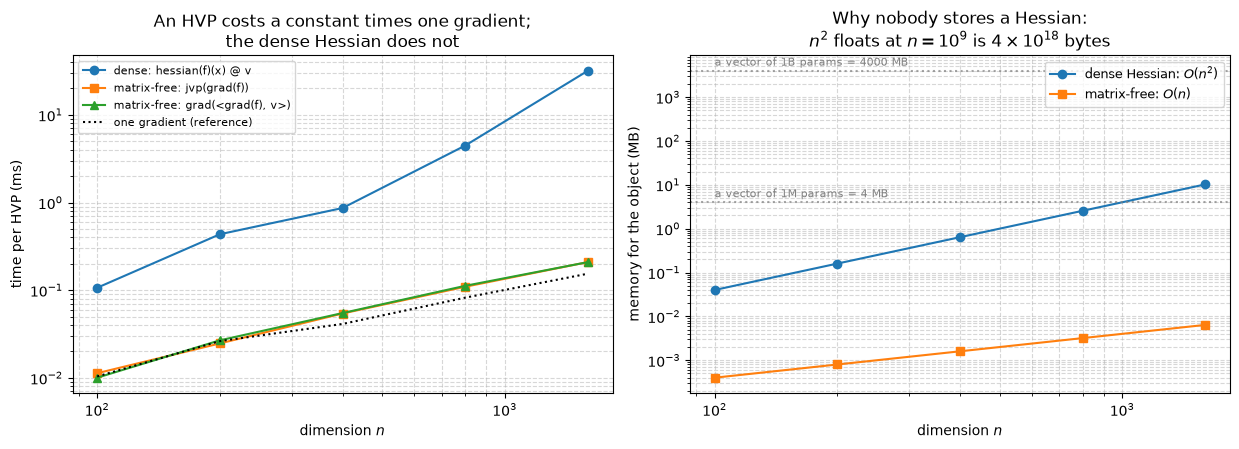

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

ax = axes[0]
ax.loglog(sizes, np.array(t_dense) * 1e3, 'o-', label='dense: hessian(f)(x) @ v')
ax.loglog(sizes, np.array(t_fwd_rev) * 1e3, 's-', label='matrix-free: jvp(grad(f))')
ax.loglog(sizes, np.array(t_rev_rev) * 1e3, '^-', label='matrix-free: grad(<grad(f), v>)')
ax.loglog(sizes, np.array(t_grad) * 1e3, ':', color='k', label='one gradient (reference)')
ax.set_xlabel('dimension $n$')
ax.set_ylabel('time per HVP (ms)')
ax.set_title('An HVP costs a constant times one gradient;\nthe dense Hessian does not')
ax.grid(True, ls='--', alpha=0.5, which='both')
ax.legend(fontsize=8)

ax = axes[1]
ax.loglog(sizes, mem_dense, 'o-', label='dense Hessian: $O(n^2)$')
ax.loglog(sizes, mem_free, 's-', label='matrix-free: $O(n)$')
for nbig, lab in [(1e6, '1M params'), (1e9, '1B params')]:
    ax.axhline(nbig * 4 / 1e6, color='gray', ls=':', alpha=0.7)
    ax.text(sizes[0], nbig * 4 / 1e6 * 1.3, f'a vector of {lab} = {nbig*4/1e6:.0f} MB',
            fontsize=8, color='gray')
ax.set_xlabel('dimension $n$')
ax.set_ylabel('memory for the object (MB)')
ax.set_title('Why nobody stores a Hessian:\n$n^2$ floats at $n = 10^9$ is $4\\times10^{18}$ bytes')
ax.grid(True, ls='--', alpha=0.5, which='both')
ax.legend(fontsize=9)

plt.tight_layout()

> **Observe:** measured in the only unit that matters — **gradients** — the theory lands.
> The `HVP / grad` ratio sits near **1x across a 16x range of $n$** with a fitted slope of
> $\approx 0$: forward-over-reverse really does buy curvature for the price of about one
> gradient, and *keeps* doing so as $n$ grows. The dense route's ratio to a gradient climbs
> with slope $\approx +0.9$, which is its $O(n)$ passes against the HVP's $O(1)$. Those two
> slopes *are* the cost model. (Individual ratios wobble by tens of percent — at ~0.1 ms
> per call, OS noise is visible even at 15 reps — so trust the trend across the sweep, not
> any single row. That is why we fit a slope instead of quoting one number.)
>
> Note what we did **not** claim. The raw `grad` and `dense` timings scale ~1 power of $n$
> below their FLOP counts, because a matrix-vector product has arithmetic intensity ~1 and
> is therefore **memory-bound** — we are timing how fast $M$ streams out of RAM, which is
> Week 1's roofline reappearing on schedule. Normalizing by one gradient divides that
> hardware effect out and leaves the pass count, which is the part that transfers to the
> GPU node.
>
> The *memory* column is the real killer anyway: at $n = 10^9$ the HVP needs a 4 GB vector
> while the Hessian would need $4\times10^{18}$ bytes — more storage than has ever been
> manufactured. Curvature is affordable; the matrix never was.


### 🔬 Exercise 3

**Exercise:** Put the HVP to work: implement **Newton-CG** (also called truncated
Newton, or Hessian-free optimization). Instead of solving $\nabla^2 f\, d = \nabla f$ with
`jnp.linalg.solve` — which needs the matrix and costs $O(n^3)$ — solve it with a few
iterations of **conjugate gradient**, which only ever asks for Hessian-vector products.
Run it on Rosenbrock and compare against both plain GD and full Newton. Then say what
this would cost on a model with $n = 10^9$.


In [27]:
# --- Reference solution (instructor: blank this out for students) ---
def cg_solve(hvp_fn, b, n_iters=20, tol=1e-10):
    # Solve H d = b using only matrix-vector products with H. No matrix, O(n) memory.
    d = jnp.zeros_like(b)
    r = b - hvp_fn(d)
    p = r
    rs = jnp.vdot(r, r)
    for _ in range(n_iters):
        Hp = hvp_fn(p)
        denom = jnp.vdot(p, Hp)
        alpha = rs / jnp.where(jnp.abs(denom) < 1e-12, 1e-12, denom)
        d = d + alpha * p
        r = r - alpha * Hp
        rs_new = jnp.vdot(r, r)
        if float(rs_new) < tol:
            break
        p = r + (rs_new / rs) * p
        rs = rs_new
    return d

def newton_cg_step(z, alpha=1.0, cg_iters=10):
    g = jax.grad(rosenbrock)(z)
    hvp_fn = lambda v: hvp_forward_over_reverse(rosenbrock, z, v)
    d = cg_solve(hvp_fn, g, n_iters=cg_iters)
    return z - alpha * d

zs_ncg, fs_ncg = run(lambda z, a: newton_cg_step(z, a), z0, 20, 1.0)

print("Rosenbrock from (-1.2, 1.0):")
print(f"{'method':>28}  {'iters':>6}  {'final f':>12}  {'Hessian formed?':>16}")
print('-' * 70)
print(f"{'gradient descent':>28}  {5000:>6}  {fs_gd[-1]:>12.3e}  {'no':>16}")
print(f"{'Newton (dense solve)':>28}  {20:>6}  {fs_nt[-1]:>12.3e}  {'yes, O(n^2) memory':>16}")
print(f"{'Newton-CG (matrix-free)':>28}  {20:>6}  {fs_ncg[-1]:>12.3e}  {'NO, O(n) memory':>16}")

print()
print("Newton-CG lands within ~1e-10 of full Newton's machine-zero, using 5000x fewer")
print("iterations than GD -- while only ever calling HVPs. It does not reach EXACT")
print("machine zero because CG is truncated at 10 iterations: we solve the Newton")
print("system approximately. That is the trade, and it is a good one.")
print("Cost at n = 1e9: each CG iteration is ~1 HVP ~ 2-3 gradients, and we used 10")
print("of them per step -> ~25 gradient-equivalents per Newton-CG step, with memory")
print("O(n) = a handful of parameter-sized vectors. The dense Newton step at that")
print("size would need 4e18 bytes for the matrix and ~1e27 FLOPs for the solve, i.e.")
print("it is not merely slow -- it is physically impossible. THIS is why Hessian-free")
print("methods exist, and it is a direct consequence of today's cost model.")

Rosenbrock from (-1.2, 1.0):
                      method   iters       final f   Hessian formed?
----------------------------------------------------------------------
            gradient descent    5000     3.761e-03                no
        Newton (dense solve)      20     0.000e+00  yes, O(n^2) memory
     Newton-CG (matrix-free)      20     6.097e-11   NO, O(n) memory

Newton-CG lands within ~1e-10 of full Newton's machine-zero, using 5000x fewer
iterations than GD -- while only ever calling HVPs. It does not reach EXACT
machine zero because CG is truncated at 10 iterations: we solve the Newton
system approximately. That is the trade, and it is a good one.
Cost at n = 1e9: each CG iteration is ~1 HVP ~ 2-3 gradients, and we used 10
of them per step -> ~25 gradient-equivalents per Newton-CG step, with memory
O(n) = a handful of parameter-sized vectors. The dense Newton step at that
size would need 4e18 bytes for the matrix and ~1e27 FLOPs for the solve, i.e.
it is not merely slow

---

## 8. `custom_vjp`: when the graph is right but the derivative is wrong

AD differentiates **the program you ran**, faithfully. Sometimes that faithfulness is
the bug. Two situations recur:

1. **Numerical instability.** The mathematical derivative is perfectly well-behaved, but
   the derivative *of the particular expression you wrote* overflows or cancels. AD has
   no way to know the algebra simplifies.
2. **You want a different derivative on purpose.** Straight-through estimators, implicit
   differentiation of a solver's fixed point, gradient clipping or reversal — cases where
   the true derivative is useless, unavailable, or not what you mean.

`jax.custom_vjp` lets you keep the forward computation and *replace the backward rule*.

The canonical instability is $\mathrm{softplus}(x) = \log(1 + e^{x})$, which appears
everywhere in ML (and, as $\log(1+e^{-x})$, inside every logistic loss). The function
itself is fine at $x = 100$: $\log(1+e^{100}) \approx 100$. Its derivative is fine too:
$\sigma(100) \approx 1$. But *the expression* computes $e^{100} = \infty$ in float32, and
AD then propagates $\infty/\infty = \mathrm{NaN}$.


In [28]:
def log1pexp_naive(x):
    return jnp.log(1.0 + jnp.exp(x))

print(f"{'x':>7}  {'value':>12}  {'jax.grad':>12}  {'true grad = sigmoid(x)':>23}")
print('-' * 60)
for xv_ in [0.0, 1.0, 10.0, 50.0, 100.0]:
    xj = jnp.float32(xv_)
    print(f"{xv_:>7.1f}  {float(log1pexp_naive(xj)):>12.4f}"
          f"  {float(jax.grad(log1pexp_naive)(xj)):>12.4f}"
          f"  {float(jax.nn.sigmoid(xj)):>23.4f}")

print()
print("At x = 100 the VALUE is already inf (exp(100) overflows float32, max ~3.4e38),")
print("and the gradient is NaN: AD computed d/dx log(1+u) = 1/(1+u) with u = inf,")
print("then multiplied by du/dx = exp(100) = inf, giving 0 * inf -> NaN.")
print("The true derivative, sigmoid(100), is a perfectly ordinary 1.0.")

      x         value      jax.grad   true grad = sigmoid(x)
------------------------------------------------------------
    0.0        0.6931        0.5000                   0.5000
    1.0        1.3133        0.7311                   0.7311
   10.0       10.0000        1.0000                   1.0000
   50.0       50.0000        1.0000                   1.0000
  100.0           inf           nan                   1.0000

At x = 100 the VALUE is already inf (exp(100) overflows float32, max ~3.4e38),
and the gradient is NaN: AD computed d/dx log(1+u) = 1/(1+u) with u = inf,
then multiplied by du/dx = exp(100) = inf, giving 0 * inf -> NaN.
The true derivative, sigmoid(100), is a perfectly ordinary 1.0.


In [29]:
# Fix the BACKWARD pass with custom_vjp: keep the forward, supply d/dx = sigmoid(x).
@jax.custom_vjp
def log1pexp(x):
    return jnp.log(1.0 + jnp.exp(x))

def log1pexp_fwd(x):
    # return (primal output, residuals the backward pass needs)
    return log1pexp(x), x

def log1pexp_bwd(res, ct):
    x = res
    # d/dx log(1+e^x) = e^x / (1+e^x) = sigmoid(x) -- stable, and never touches inf
    return (ct * jax.nn.sigmoid(x),)

log1pexp.defvjp(log1pexp_fwd, log1pexp_bwd)

print(f"{'x':>7}  {'grad (naive)':>14}  {'grad (custom_vjp)':>18}  {'true sigmoid(x)':>16}")
print('-' * 62)
for xv_ in [0.0, 1.0, 10.0, 50.0, 100.0]:
    xj = jnp.float32(xv_)
    print(f"{xv_:>7.1f}  {float(jax.grad(log1pexp_naive)(xj)):>14.4f}"
          f"  {float(jax.grad(log1pexp)(xj)):>18.4f}"
          f"  {float(jax.nn.sigmoid(xj)):>16.4f}")

print()
print("The custom rule is correct everywhere. Note the forward pass still overflows at")
print("x = 100 -- custom_vjp fixed the DERIVATIVE, not the value. A production softplus")
print("also rewrites the forward as maximum(x, 0) + log1p(exp(-|x|)); jax.nn.softplus")
print("does exactly that. Fix the pass that is broken, and know which one that is.")

      x    grad (naive)   grad (custom_vjp)   true sigmoid(x)
--------------------------------------------------------------
    0.0          0.5000              0.5000            0.5000
    1.0          0.7311              0.7311            0.7311
   10.0          1.0000              1.0000            1.0000
   50.0          1.0000              1.0000            1.0000
  100.0             nan              1.0000            1.0000

The custom rule is correct everywhere. Note the forward pass still overflows at
x = 100 -- custom_vjp fixed the DERIVATIVE, not the value. A production softplus
also rewrites the forward as maximum(x, 0) + log1p(exp(-|x|)); jax.nn.softplus
does exactly that. Fix the pass that is broken, and know which one that is.


> **Observe:** the naive gradient is NaN from around $x \approx 89$ (where `exp` overflows
> float32) while the custom rule returns the correct $\sigma(x)$ for every input. This is
> the deepest idea in the lab: **AD is exact with respect to your program, and your
> program may not be the function you meant.** A NaN in training is very often not a bug
> in JAX and not a bad learning rate — it is AD being scrupulously correct about an
> expression that should have been rewritten.


### Verify your rule — `custom_vjp` disables the safety net

`custom_vjp` hands you a loaded weapon. AD's great virtue is that it cannot get the
derivative of your program wrong; the moment you override it, that guarantee is *yours*
to uphold. A typo in a backward rule does not raise — it silently trains a slightly wrong
model, which is among the hardest bugs in ML to find.

So how do you check a hand-written derivative? With the method Section 1 spent all that
effort discrediting. Finite differences are a lousy way to *compute* a gradient — 3 good
digits — but 3 digits is plenty to catch a *wrong* one, and crucially FD is an
**independent** implementation: it shares no code with your rule, so it cannot share your
mistake. That is exactly what a test needs. `jax.test_util.check_grads` automates it.


In [30]:
from jax.test_util import check_grads

# A deliberately sabotaged rule: correct to within 5%. Small enough to survive a
# glance at a loss curve, large enough to poison a long training run.
@jax.custom_vjp
def log1pexp_buggy(x):
    return jnp.log(1.0 + jnp.exp(x))

def log1pexp_buggy_fwd(x):
    return log1pexp_buggy(x), x

def log1pexp_buggy_bwd(res, ct):
    return (ct * jax.nn.sigmoid(res) * 1.05,)     # <-- the bug: 5% too big

log1pexp_buggy.defvjp(log1pexp_buggy_fwd, log1pexp_buggy_bwd)

x_chk = jnp.float32(0.7)
print(f"At x = {float(x_chk)}, the two rules look almost identical:")
print(f"  correct rule : {float(jax.grad(log1pexp)(x_chk)):.6f}")
print(f"  buggy rule   : {float(jax.grad(log1pexp_buggy)(x_chk)):.6f}   <- would you notice?")
print()

for name, fn in [("correct rule", log1pexp), ("buggy rule", log1pexp_buggy)]:
    try:
        check_grads(fn, (x_chk,), order=1, modes=['rev'], atol=1e-2, rtol=1e-2)
        print(f"  {name:>13}: check_grads PASSED")
    except AssertionError as e:
        first = str(e).strip().split('\n')[0]
        print(f"  {name:>13}: check_grads FAILED -> {first}")

print()
print("check_grads differentiates numerically and compares against your VJP. The 5%")
print("error is far above finite-difference noise, so it is caught easily -- FD's 3")
print("good digits are useless as a gradient and ample as a test. Write a check_grads")
print("test for every custom_vjp you ever ship.")

At x = 0.699999988079071, the two rules look almost identical:
  correct rule : 0.668188


  buggy rule   : 0.701597   <- would you notice?

   correct rule: check_grads PASSED
     buggy rule: check_grads FAILED -> Not equal to tolerance rtol=0.01, atol=0.01

check_grads differentiates numerically and compares against your VJP. The 5%
error is far above finite-difference noise, so it is caught easily -- FD's 3
good digits are useless as a gradient and ample as a test. Write a check_grads
test for every custom_vjp you ever ship.


> **Observe:** the buggy rule is off by 5% — invisible in a printed number, fatal over a
> long run — and `check_grads` catches it instantly, while the correct rule passes. Note
> the pleasing inversion: the technique Section 1 rejected for *computing* gradients is
> the right tool for *testing* them, precisely because it is independent of the code under
> test. Bad numerics, good oracle.


### 🔬 Exercise 4

**Exercise:** Use `custom_vjp` for the *other* reason — to install a derivative that is
deliberately not the true one. **Quantization** rounds a value to a grid; its true
derivative is zero almost everywhere and undefined on the grid points, so gradients
cannot flow through it and training dies instantly. The **straight-through estimator
(STE)** fixes this by rounding on the forward pass and pretending the backward pass saw
the identity.

Implement an STE quantizer, show that the naive version kills the gradient and the STE
version does not, then train a toy model *through* the quantizer. You will meet this
again in **Week 10**, where quantizing the model update is how federated learning cuts
its communication bill.


In [31]:
# --- Reference solution (instructor: blank this out for students) ---
def quantize_naive(x, levels=9):
    # Round to an evenly spaced grid on [-1, 1] (9 levels, spacing 0.25).
    # Piecewise constant -> derivative is 0 almost everywhere, undefined on the grid.
    scale = (levels - 1) / 2.0
    return jnp.round(x * scale) / scale

@jax.custom_vjp
def quantize_ste(x, levels=8):
    scale = (levels - 1) / 2.0
    return jnp.round(x * scale) / scale

def quantize_ste_fwd(x, levels=9):
    return quantize_ste(x, levels), None

def quantize_ste_bwd(res, ct):
    # Straight-through: pretend the forward pass was the identity.
    # The (None,) is the cotangent for `levels`, which is not differentiated.
    return (ct, None)

quantize_ste.defvjp(quantize_ste_fwd, quantize_ste_bwd)

xs_q = jnp.linspace(-1.0, 1.0, 9)
g_naive = jax.vmap(jax.grad(lambda z: jnp.sum(quantize_naive(z))))(xs_q.reshape(-1, 1))
g_ste   = jax.vmap(jax.grad(lambda z: jnp.sum(quantize_ste(z))))(xs_q.reshape(-1, 1))

print(f"{'x':>7}  {'quantize(x)':>12}  {'grad naive':>11}  {'grad STE':>9}")
print('-' * 45)
for i in range(len(xs_q)):
    print(f"{float(xs_q[i]):>7.3f}  {float(quantize_naive(xs_q[i])):>12.3f}"
          f"  {float(g_naive[i][0]):>11.1f}  {float(g_ste[i][0]):>9.1f}")

print("\nThe naive gradient is 0 everywhere: true, useless, and fatal to training.")
print("The STE gradient is 1: false, but it is the lie that makes learning possible.")

      x   quantize(x)   grad naive   grad STE
---------------------------------------------


 -1.000        -1.000          0.0        1.0
 -0.750        -0.750          0.0        1.0
 -0.500        -0.500          0.0        1.0
 -0.250        -0.250          0.0        1.0
  0.000         0.000          0.0        1.0
  0.250         0.250          0.0        1.0
  0.500         0.500          0.0        1.0
  0.750         0.750          0.0        1.0
  1.000         1.000          0.0        1.0

The naive gradient is 0 everywhere: true, useless, and fatal to training.
The STE gradient is 1: false, but it is the lie that makes learning possible.


training through a quantizer, 300 steps of SGD
  naive quantizer: loss 4.1958 -> 4.1958   (moved: False)
  STE   quantizer: loss 3.4286 -> 0.3069   (moved: True)

  STE reduced the loss by 11.2x; the naive version is frozen at its
  initialization because every gradient it ever received was exactly zero.


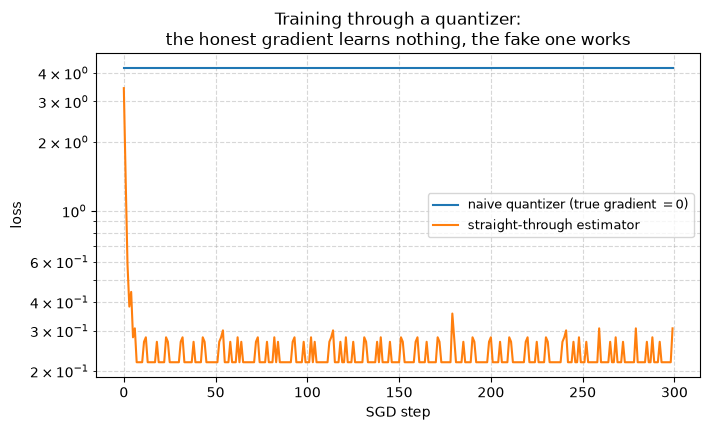

In [32]:
# Now train THROUGH the quantizer and watch the difference in outcomes.
W_true = jnp.asarray(rng.normal(size=(6,)), dtype=jnp.float32)
Xd = jnp.asarray(rng.normal(size=(128, 6)), dtype=jnp.float32)
Yd = Xd @ W_true

def make_loss(qfn):
    def loss_fn(w):
        return jnp.mean((Xd @ qfn(jnp.tanh(w)) - Yd) ** 2)
    return loss_fn

def train(qfn, steps=300, lr=0.3):
    w = jnp.asarray(rng.normal(size=(6,)) * 0.1, dtype=jnp.float32)
    gfn = jax.jit(jax.value_and_grad(make_loss(qfn)))
    hist = []
    for _ in range(steps):
        v, g = gfn(w)
        w = w - lr * g
        hist.append(float(v))
    return np.array(hist), w

hist_naive, w_naive = train(quantize_naive)
hist_ste, w_ste = train(quantize_ste)

print(f"training through a quantizer, {len(hist_naive)} steps of SGD")
print(f"  naive quantizer: loss {hist_naive[0]:.4f} -> {hist_naive[-1]:.4f}   (moved: {abs(hist_naive[-1]-hist_naive[0]) > 1e-6})")
print(f"  STE   quantizer: loss {hist_ste[0]:.4f} -> {hist_ste[-1]:.4f}   (moved: {abs(hist_ste[-1]-hist_ste[0]) > 1e-6})")
print(f"\n  STE reduced the loss by {hist_ste[0]/max(hist_ste[-1], 1e-9):.1f}x; the naive version is frozen at its")
print("  initialization because every gradient it ever received was exactly zero.")

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.semilogy(hist_naive, label='naive quantizer (true gradient $= 0$)')
ax.semilogy(hist_ste, label='straight-through estimator')
ax.set_xlabel('SGD step'); ax.set_ylabel('loss')
ax.set_title('Training through a quantizer:\nthe honest gradient learns nothing, the fake one works')
ax.grid(True, ls='--', alpha=0.5, which='both')
ax.legend(fontsize=9)
plt.tight_layout()

> **Observe:** the naive curve is a flat line — not slow, *stationary*, because a
> gradient of exactly zero moves nothing. The STE curve drops several orders of magnitude
> using a backward rule that is mathematically wrong on purpose. Keep this in your pocket
> for Week 10: when we quantize model updates to cut FL communication by 8–32x, this is
> the mechanism that lets the clients still learn.


---

## Summary

- **AD is not finite differences and not symbolic differentiation.** It evaluates the
  chain rule numerically at a point, reusing intermediates: exact to machine precision,
  with no step size to tune and no expression swell. We measured finite differences
  bottoming out at ~$10^{-4}$ *relative* error in float32 — about $400\times$ worse than
  AD, at their *best* $h$, which you would have had to know in advance.
- **Two primitives, and everything is built from them.** Forward mode computes a JVP
  ($J v$, one **column**); reverse mode computes a VJP ($u^{\top} J$, one **row**). We
  built `jacfwd` and `jacrev` by hand from `jax.jvp` and `jax.vjp` to prove it.
- **The cost model is the lab's core.** For $f:\mathbb{R}^n \to \mathbb{R}^m$: forward
  costs $O(n)$ passes, reverse costs $O(m)$ passes. Use reverse when $m \ll n$, forward
  when $n \ll m$; the crossover is at $n \approx m$ — and our measurement put it exactly
  at $n = m = 32$. Each mode was flat (slope $\approx +0.2$) in the dimension it does not
  pay for and clearly growing in the one it does, though the growing slope measured
  $\approx +0.6$ rather than $+1$: `vmap` batches the passes into one wide matmul, so the
  machine does not charge full price per pass. **The law counts arithmetic; the hardware
  decides what that arithmetic costs.**
- **Deep learning is the corner case $m = 1$**, where reverse mode gives a gradient for
  $O(1)$ times the cost of the function regardless of $n$ — the cheap gradient principle.
  The price is the tape: reverse mode's memory grows with graph depth, which is the
  constraint Week 6 attacks with `remat`.
- **Compose AD by applying the cost model twice.** `jacfwd(jacrev(f))` is $O(n)$ while
  `jacrev(jacfwd(f))` is $O(n^2)$ for the *same matrix*, because only reverse-on-the-inside
  gets to exploit $m=1$. Put reverse mode as deep inside as possible. That is why
  `jax.hessian` is defined the way it is.
- **Curvature is affordable; the Hessian is not.** Newton converges quadratically — but
  *locally*: from a hard start the full step overshot and made $f$ 58x **worse** before
  the digits began doubling, with a positive-definite Hessian the whole time. And it needs
  $O(n^2)$ memory and $O(n^3)$ per solve. The Hessian-vector product
  $\nabla^2 f\,v = \texttt{jvp}(\nabla f, x, v)$ costs about **one gradient**, measured flat
  (slope $\approx 0$) across a 16x range of $n$, with $O(n)$ memory — and it is all that
  Newton-CG, Lanczos, or K-FAC ever need.
- **`custom_vjp` overrides the backward pass**, for correctness (softplus: AD returns NaN
  where the true derivative is a placid $\sigma(x)$) or by design (the straight-through
  estimator, which returns Week 10 for quantized FL communication).
- **Thread:** the gradient we computed today is the object the entire rest of the course
  moves, compresses, averages, attacks, and defends. Week 3 gives it a home in an
  Equinox/Optax codebase; Weeks 5–7 send it across devices; Weeks 9–13 send it across
  organizations, where it becomes both a privacy leak and an attack surface.

### Further Exercises

1. **(Pencil)** A function $f:\mathbb{R}^{1000}\to\mathbb{R}^{1000}$ takes 10 ms to
   evaluate. Estimate the wall-clock cost of its full Jacobian via `jacfwd` and via
   `jacrev`, then via `jacfwd` of a `vmap`ped version. Which would you actually run, and
   what would you do instead if you only needed $J v$ for 5 vectors $v$?
2. **(Pencil)** Show that the Gauss-Newton matrix $J^{\top} J$ for a least-squares
   residual $r:\mathbb{R}^n\to\mathbb{R}^m$ admits a matrix-free product
   $v \mapsto J^{\top}(J v)$ costing one JVP plus one VJP. Why is this preferable to the
   true Hessian for optimization, beyond just cost?
3. **(Numerical)** Implement `hessian` yourself as `jacfwd(jacrev(f))` and verify it
   against `jax.hessian` on Rosenbrock. Then implement it as `vmap` of HVPs against the
   basis vectors and verify all three agree. Time them at $n = 500$ and explain the
   ranking.
4. **(Numerical)** Take the Section 4 crossover experiment to the GPU node. The pass
   counts cannot change, but the *timings* will: at what $n$ does `jacfwd` stop looking
   linear, and why? (Hint: `jacfwd` `vmap`s its $n$ passes into one batched kernel. What
   happens while that batch is smaller than the machine?)
5. **(Numerical)** Use `jax.custom_vjp` to implement a gradient-reversal layer (identity
   forward, $-\lambda \cdot$ gradient backward) and use it to train a tiny
   domain-adversarial classifier. Note that this is *the same mechanism* as the STE:
   forward and backward decoupled on purpose.
6. **(Numerical)** Estimate the largest eigenvalue of the Hessian of a small MLP's loss
   using only HVPs (power iteration: $v \leftarrow Hv/\|Hv\|$). This is how people measure
   the sharpness of a minimum — and it never forms $H$. Compare against
   `jnp.linalg.eigvalsh(jax.hessian(...))` at a size where the dense route still fits.
7. **(Open)** Read the `jax.checkpoint` (`jax.remat`) documentation and explain, in terms
   of today's tape, what it trades and why the trade is worth it. Predict what it does to
   the HVP timings in Section 7.
